#
Projet UA 2 – Prédiction des matchs de football

1. Analyse exploratoire des données

In [440]:
import pandas as pd
pd.set_option('display.max_columns', 20)  # Affiche jusqu'à 20 colonnes
pd.set_option('display.max_rows', 100)    # Affiche jusqu'à 100 lignes
pd.set_option('display.max_colwidth', 50) # Limite la largeur des colonnes à 50 caractères

###
 Ce bloc de code configure les options d'affichage de Pandas pour améliorer la lisibilité des DataFrames

In [441]:
import pandas as pd
df = pd.read_csv("football.csv") 
# Nous chargeons ici les donnees du fichier football.csv pour commencer l'analyse des données

In [442]:
df
#Nous avons afficher les données du fichier football.csv.

,id,date,home_team,away_team,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,...,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target,match_type
0,2221,2021-09-09,Brazil,Peru,-1.0,-5.0,2.028571,0.8,0.371429,0.4,...,1.027778,1.4,1.583333,1.6,24.388889,21.2,8.16,31.28,0,Friendly
1,507,2019-05-29,Comoros,Mauritius,5.0,NaN,1.166667,1.2,1.666667,1.8,...,1.200000,1.2,1.200000,1.2,159.800000,159.8,-6.00,-6.00,0,Friendly
2,1545,2020-11-18,Serbia,Russia,-1.0,NaN,1.608696,1.2,1.347826,1.2,...,2.136364,0.8,1.045455,1.2,65.681818,62.0,70.00,-5.00,0,Friendly
3,2067,2021-09-01,Senegal,Togo,-1.0,NaN,1.482759,1.4,0.620690,0.8,...,0.857143,0.8,1.214286,1.2,104.500000,82.0,-31.86,-22.86,0,Friendly
4,4448,2024-03-22,Peru,Nicaragua,-2.0,NaN,0.968750,0.2,1.265625,1.6,...,1.600000,3.0,1.244444,0.2,132.200000,169.4,-21.30,23.59,0,Competition
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,2020,2021-07-12,Jamaica,Suriname,0.0,NaN,2.000000,1.0,1.090909,2.0,...,3.181818,3.4,NaN,1.0,154.636364,153.6,53.43,37.43,0,Friendly
3773,696,2019-06-28,Colombia,Chile,1.0,NaN,1.909091,2.0,0.545455,0.0,...,1.545455,1.8,1.272727,0.8,39.090909,44.2,-9.00,-4.00,1,Friendly
3774,2325,2021-10-11,Mozambique,Cameroon,3.0,4.0,1.000000,0.6,1.153846,1.6,...,1.086957,1.2,0.478261,0.2,88.260870,86.2,-11.54,-22.54,1,Friendly
3775,3301,2022-11-19,Colombia,Paraguay,0.0,NaN,1.319149,2.4,0.872340,0.6,...,0.909091,0.8,1.272727,0.6,34.886364,31.2,-28.23,5.47,0,Competition


In [443]:
df.info()
df.shape[0]
# Nous listons ici toutes les colonnes et leurs types.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3777 entries, 0 to 3776
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      3777 non-null   int64  
 1   date                    3777 non-null   object 
 2   home_team               3777 non-null   object 
 3   away_team               3777 non-null   object 
 4   rank_change_home        3777 non-null   float64
 5   rank_change_away        1735 non-null   float64
 6   home_goals_mean         3777 non-null   float64
 7   home_goals_mean_l5      3777 non-null   float64
 8   home_goals_suf_mean     3753 non-null   float64
 9   home_goals_suf_mean_l5  3777 non-null   float64
 10  home_rank_mean          3777 non-null   float64
 11  home_rank_mean_l5       3777 non-null   float64
 12  home_points_mean        3763 non-null   float64
 13  home_points_mean_l5     3777 non-null   float64
 14  away_goals_mean         3777 non-null   

3777

### Nous avons 3777 lignes total dans notre fichier football.csv.

In [444]:
df.describe()
# Nous voulons ici calculer les stats comme de la moyenne, écart type, min, max, et les quartiles.

,id,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,home_rank_mean_l5,home_points_mean,home_points_mean_l5,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target
count,3777.000000,3777.000000,1735.000000,3777.000000,3777.000000,3753.000000,3777.000000,3777.000000,3777.000000,3763.000000,3777.000000,3777.000000,3777.000000,3760.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000,3777.000000
mean,2355.448239,0.079958,0.042651,1.363972,1.356985,1.250658,1.290778,85.690572,84.750613,20.283917,1.424337,1.305654,1.303954,1.320218,1.343800,88.096724,87.014606,10.293439,0.740582,0.523167
std,1350.540070,4.990718,2.428546,0.605170,0.834692,0.683486,0.867303,36.061328,40.272798,62.542519,17.099149,0.601565,0.818420,0.737387,0.907621,36.338822,40.854255,57.171734,16.789257,0.499529
min,0.000000,-28.000000,-24.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,-166.940000,-72.040000,0.000000,0.000000,0.000000,0.000000,4.750000,4.750000,-170.340000,-72.040000,0.000000
25%,1190.000000,-1.000000,-1.000000,1.000000,0.800000,0.857143,0.800000,55.818182,54.800000,-16.000000,-7.400000,0.923077,0.800000,0.910308,0.800000,58.964286,56.600000,-21.890000,-8.120000,0.000000
50%,2362.000000,0.000000,0.000000,1.285714,1.200000,1.125000,1.200000,85.842105,81.800000,7.000000,0.000000,1.212121,1.200000,1.181818,1.200000,88.583333,84.000000,2.000000,0.000000,1.000000
75%,3517.000000,1.000000,1.000000,1.704545,1.800000,1.500000,1.600000,104.707317,110.600000,49.960000,9.130000,1.625000,1.800000,1.576923,1.800000,107.333333,114.200000,37.570000,8.710000,1.000000
max,4721.000000,188.000000,14.000000,6.000000,6.400000,11.000000,11.000000,201.000000,206.200000,287.290000,138.000000,6.000000,6.000000,9.500000,9.500000,210.000000,210.000000,287.290000,140.000000,1.000000


# Résumé statistique en plus de details:

In [445]:
df.columns
# afficher les colonnes du DataFrame

Index(['id', 'date', 'home_team', 'away_team', 'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5', 'target', 'match_type'],
      dtype='object')

In [446]:
Les_columns_des_index = ['rank_change_home', 'rank_change_away', 'home_goals_mean', 'home_goals_suf_mean', 
                     'home_rank_mean', 'home_points_mean', 'away_goals_mean', 'away_goals_suf_mean', 
                     'away_rank_mean', 'away_points_mean']

# En analyse les colomnes avec DESCRIBE nous voulions regarger de plus proche ces colones afin de confirmer les informations dont nous devons apporter plus d'éclaircissement apres leur analyse.

rank_change_home
 count    3777.000000
mean        0.079958
std         4.990718
min       -28.000000
25%        -1.000000
50%         0.000000
75%         1.000000
max       188.000000
Name: rank_change_home, dtype: float64


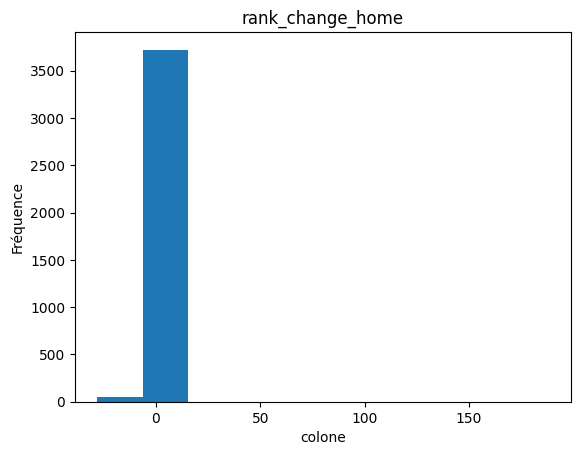


rank_change_away
 count    1735.000000
mean        0.042651
std         2.428546
min       -24.000000
25%        -1.000000
50%         0.000000
75%         1.000000
max        14.000000
Name: rank_change_away, dtype: float64


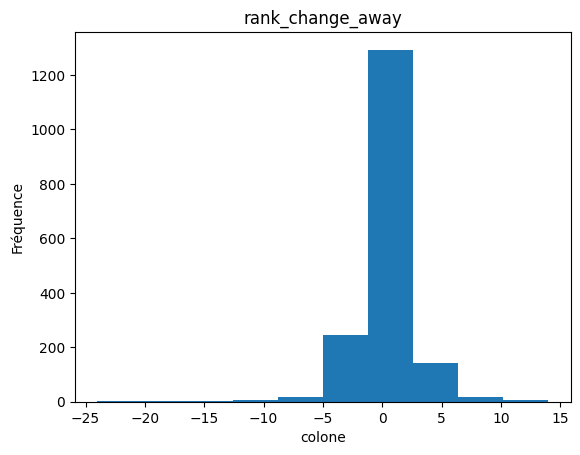


home_goals_mean
 count    3777.000000
mean        1.363972
std         0.605170
min         0.000000
25%         1.000000
50%         1.285714
75%         1.704545
max         6.000000
Name: home_goals_mean, dtype: float64


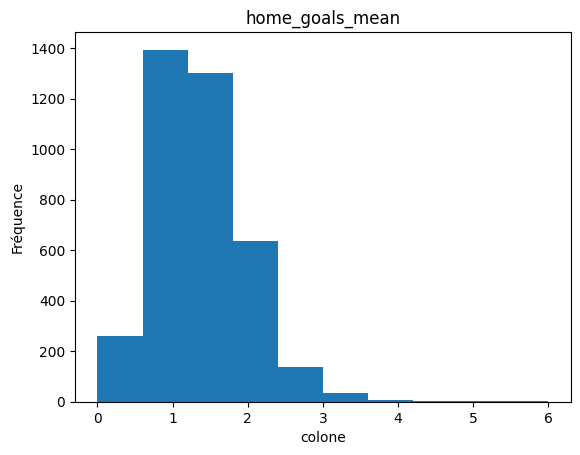


home_goals_suf_mean
 count    3753.000000
mean        1.250658
std         0.683486
min         0.000000
25%         0.857143
50%         1.125000
75%         1.500000
max        11.000000
Name: home_goals_suf_mean, dtype: float64


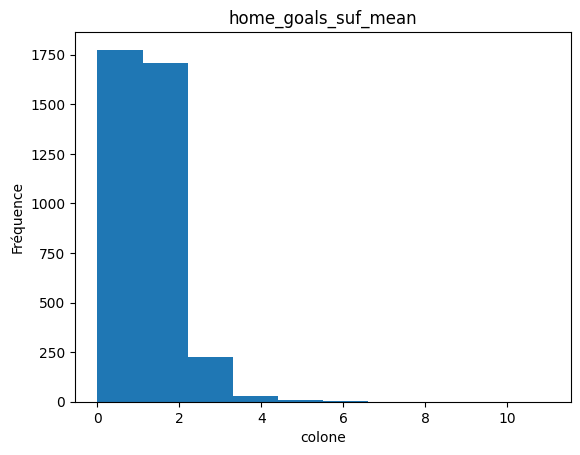


home_rank_mean
 count    3777.000000
mean       85.690572
std        36.061328
min         1.000000
25%        55.818182
50%        85.842105
75%       104.707317
max       201.000000
Name: home_rank_mean, dtype: float64


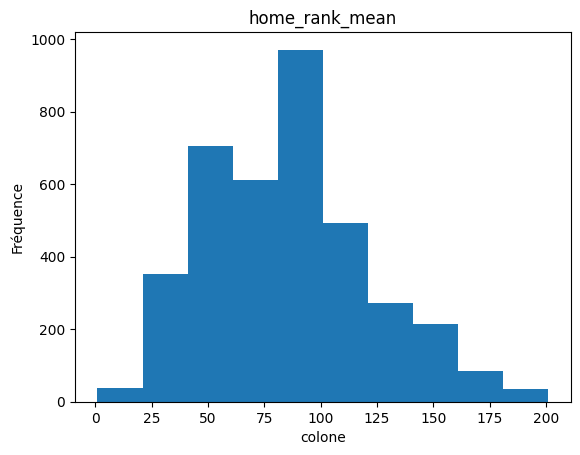


home_points_mean
 count    3763.000000
mean       20.283917
std        62.542519
min      -166.940000
25%       -16.000000
50%         7.000000
75%        49.960000
max       287.290000
Name: home_points_mean, dtype: float64


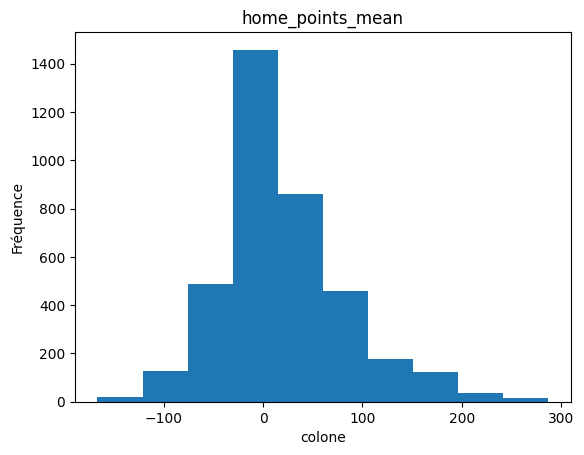


away_goals_mean
 count    3777.000000
mean        1.305654
std         0.601565
min         0.000000
25%         0.923077
50%         1.212121
75%         1.625000
max         6.000000
Name: away_goals_mean, dtype: float64


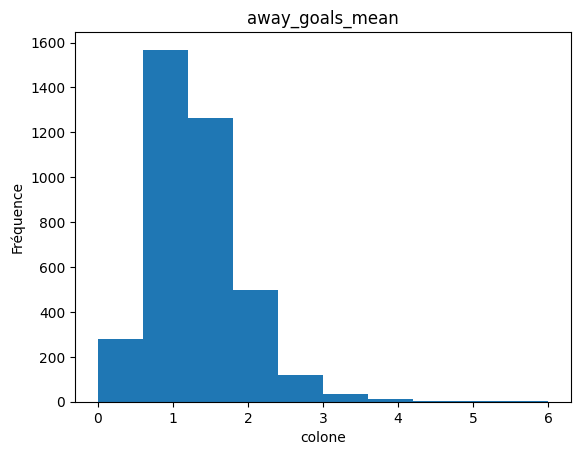


away_goals_suf_mean
 count    3760.000000
mean        1.320218
std         0.737387
min         0.000000
25%         0.910308
50%         1.181818
75%         1.576923
max         9.500000
Name: away_goals_suf_mean, dtype: float64


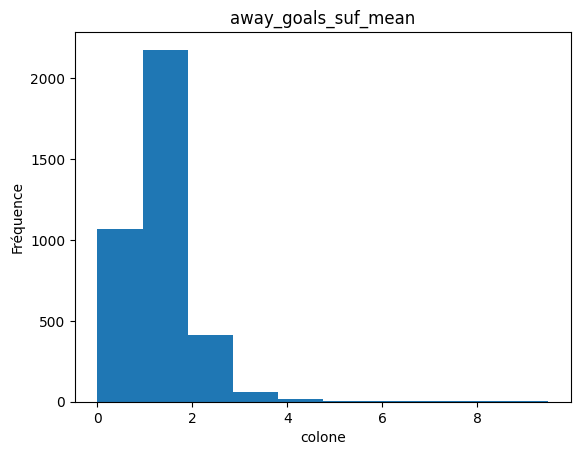


away_rank_mean
 count    3777.000000
mean       88.096724
std        36.338822
min         4.750000
25%        58.964286
50%        88.583333
75%       107.333333
max       210.000000
Name: away_rank_mean, dtype: float64


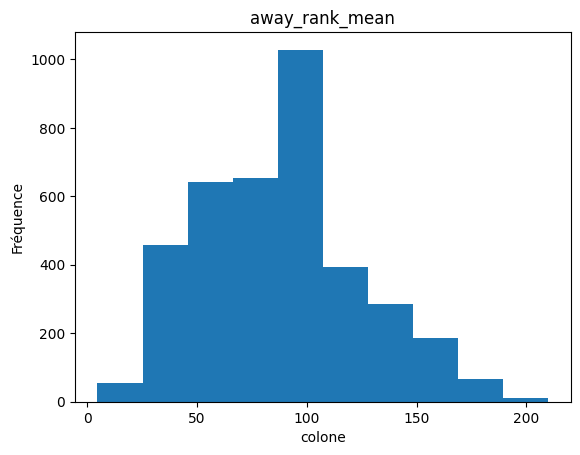


away_points_mean
 count    3777.000000
mean       10.293439
std        57.171734
min      -170.340000
25%       -21.890000
50%         2.000000
75%        37.570000
max       287.290000
Name: away_points_mean, dtype: float64


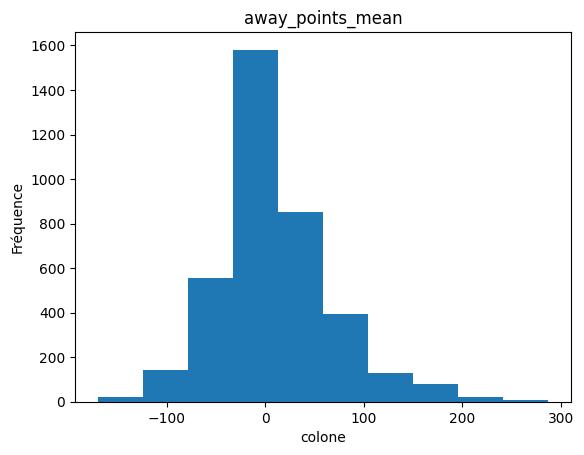

<Axes: >

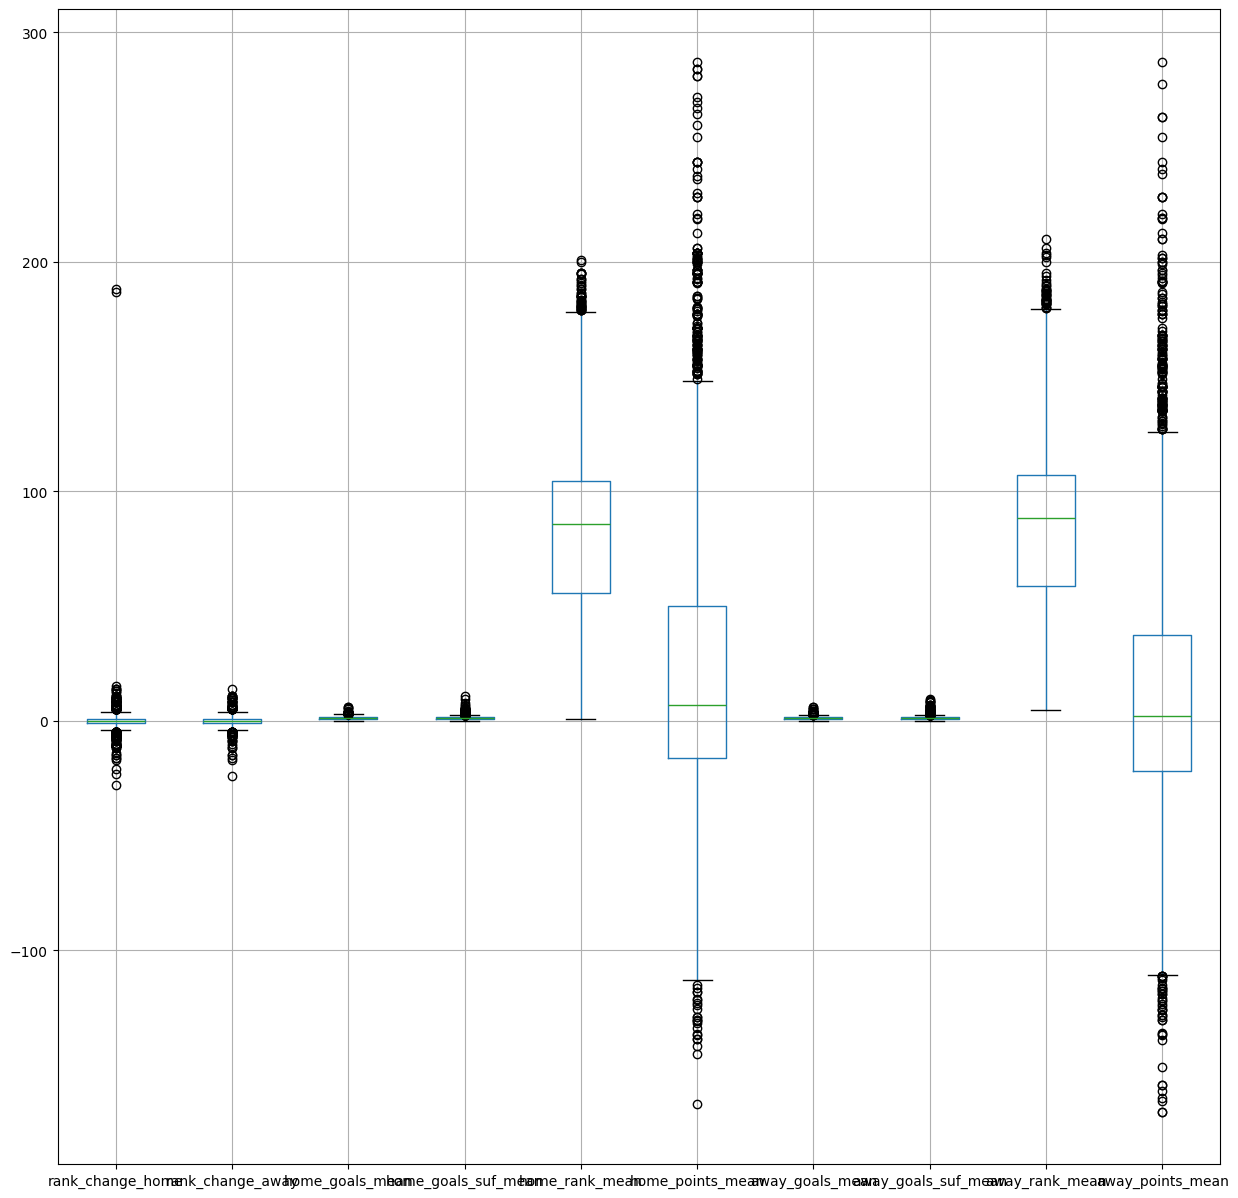

In [447]:
import matplotlib.pyplot as plt

for colone in Les_columns_des_index: 
    print(colone)
    print(f" {df[colone].describe()}")
    plt.hist(df[colone])  
    plt.title(colone)
    plt.xlabel('colone')
    plt.ylabel('Fréquence')
    plt.show()

    print("")
    
df[Les_columns_des_index].boxplot(figsize=(15,15)) 

# Nous utilisons Matplotlib pour analyser visuellement la distribution et la dispersion des données dans notre DataFrame


### D'abord nous constatons une distributions asymétrique; la plupart des colonnes liées aux buts (home_goals_mean, away_goals_mean, etc) et aux points (home_points_mean, away_points_mean) montrent des distributions asymétriques à droite.
### Ensuite la dispersion est importante car les colonnes liées aux classements (home_rank_mean, away_rank_mean) et aux points montrent une dispersion importante.
### Enfin nous constatons que Plusieurs colonnes présentent des valeurs extrêmes et les données présentent des valeurs aberrantes importantes.

In [448]:
df.columns

Index(['id', 'date', 'home_team', 'away_team', 'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5', 'target', 'match_type'],
      dtype='object')

### Analyse de home_team et away_team

In [449]:
df['home_team'].value_counts()
# Nous comptons ici le nombre de match jouer a domicile afin de savoir quelles equipes ont jouees le pus de match a domicile

home_team
Mexico            50
United States     49
Qatar             45
Bahrain           44
Japan             43
                  ..
Anguilla           3
Guam               3
Cook Islands       2
Tonga              2
American Samoa     2
Name: count, Length: 195, dtype: int64

#### Mixeco et USA ont joué plus de maths à domicile et le Quatar vient en 3e position

In [450]:
df.groupby(['home_team', 'target'])['target'].count().sort_values(ascending=0)
# permet d’obtenir une fréquence des valeurs de target par équipe à domicile.
# nous voulons savoir ici quelles sont les équipes qui ont le plus souvent atteint une certaine valeur cible (target) afin analyser la performance des équipes en fonction de target (victoires ou défaites).


home_team      target
United States  0         33
Brazil         0         28
Morocco        0         28
Japan          0         27
Argentina      0         26
                         ..
South Sudan    0          1
Tahiti         1          1
Bhutan         0          1
Togo           0          1
Afghanistan    0          1
Name: target, Length: 381, dtype: int64

#### Apres analyse nous constatons que l'equipe USA a jouer 33 match et a gagner 33 match a domicile

(array([ 0., 10., 20., 30., 40., 50., 60.]),
 [Text(0.0, 0, '0'),
  Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60')])

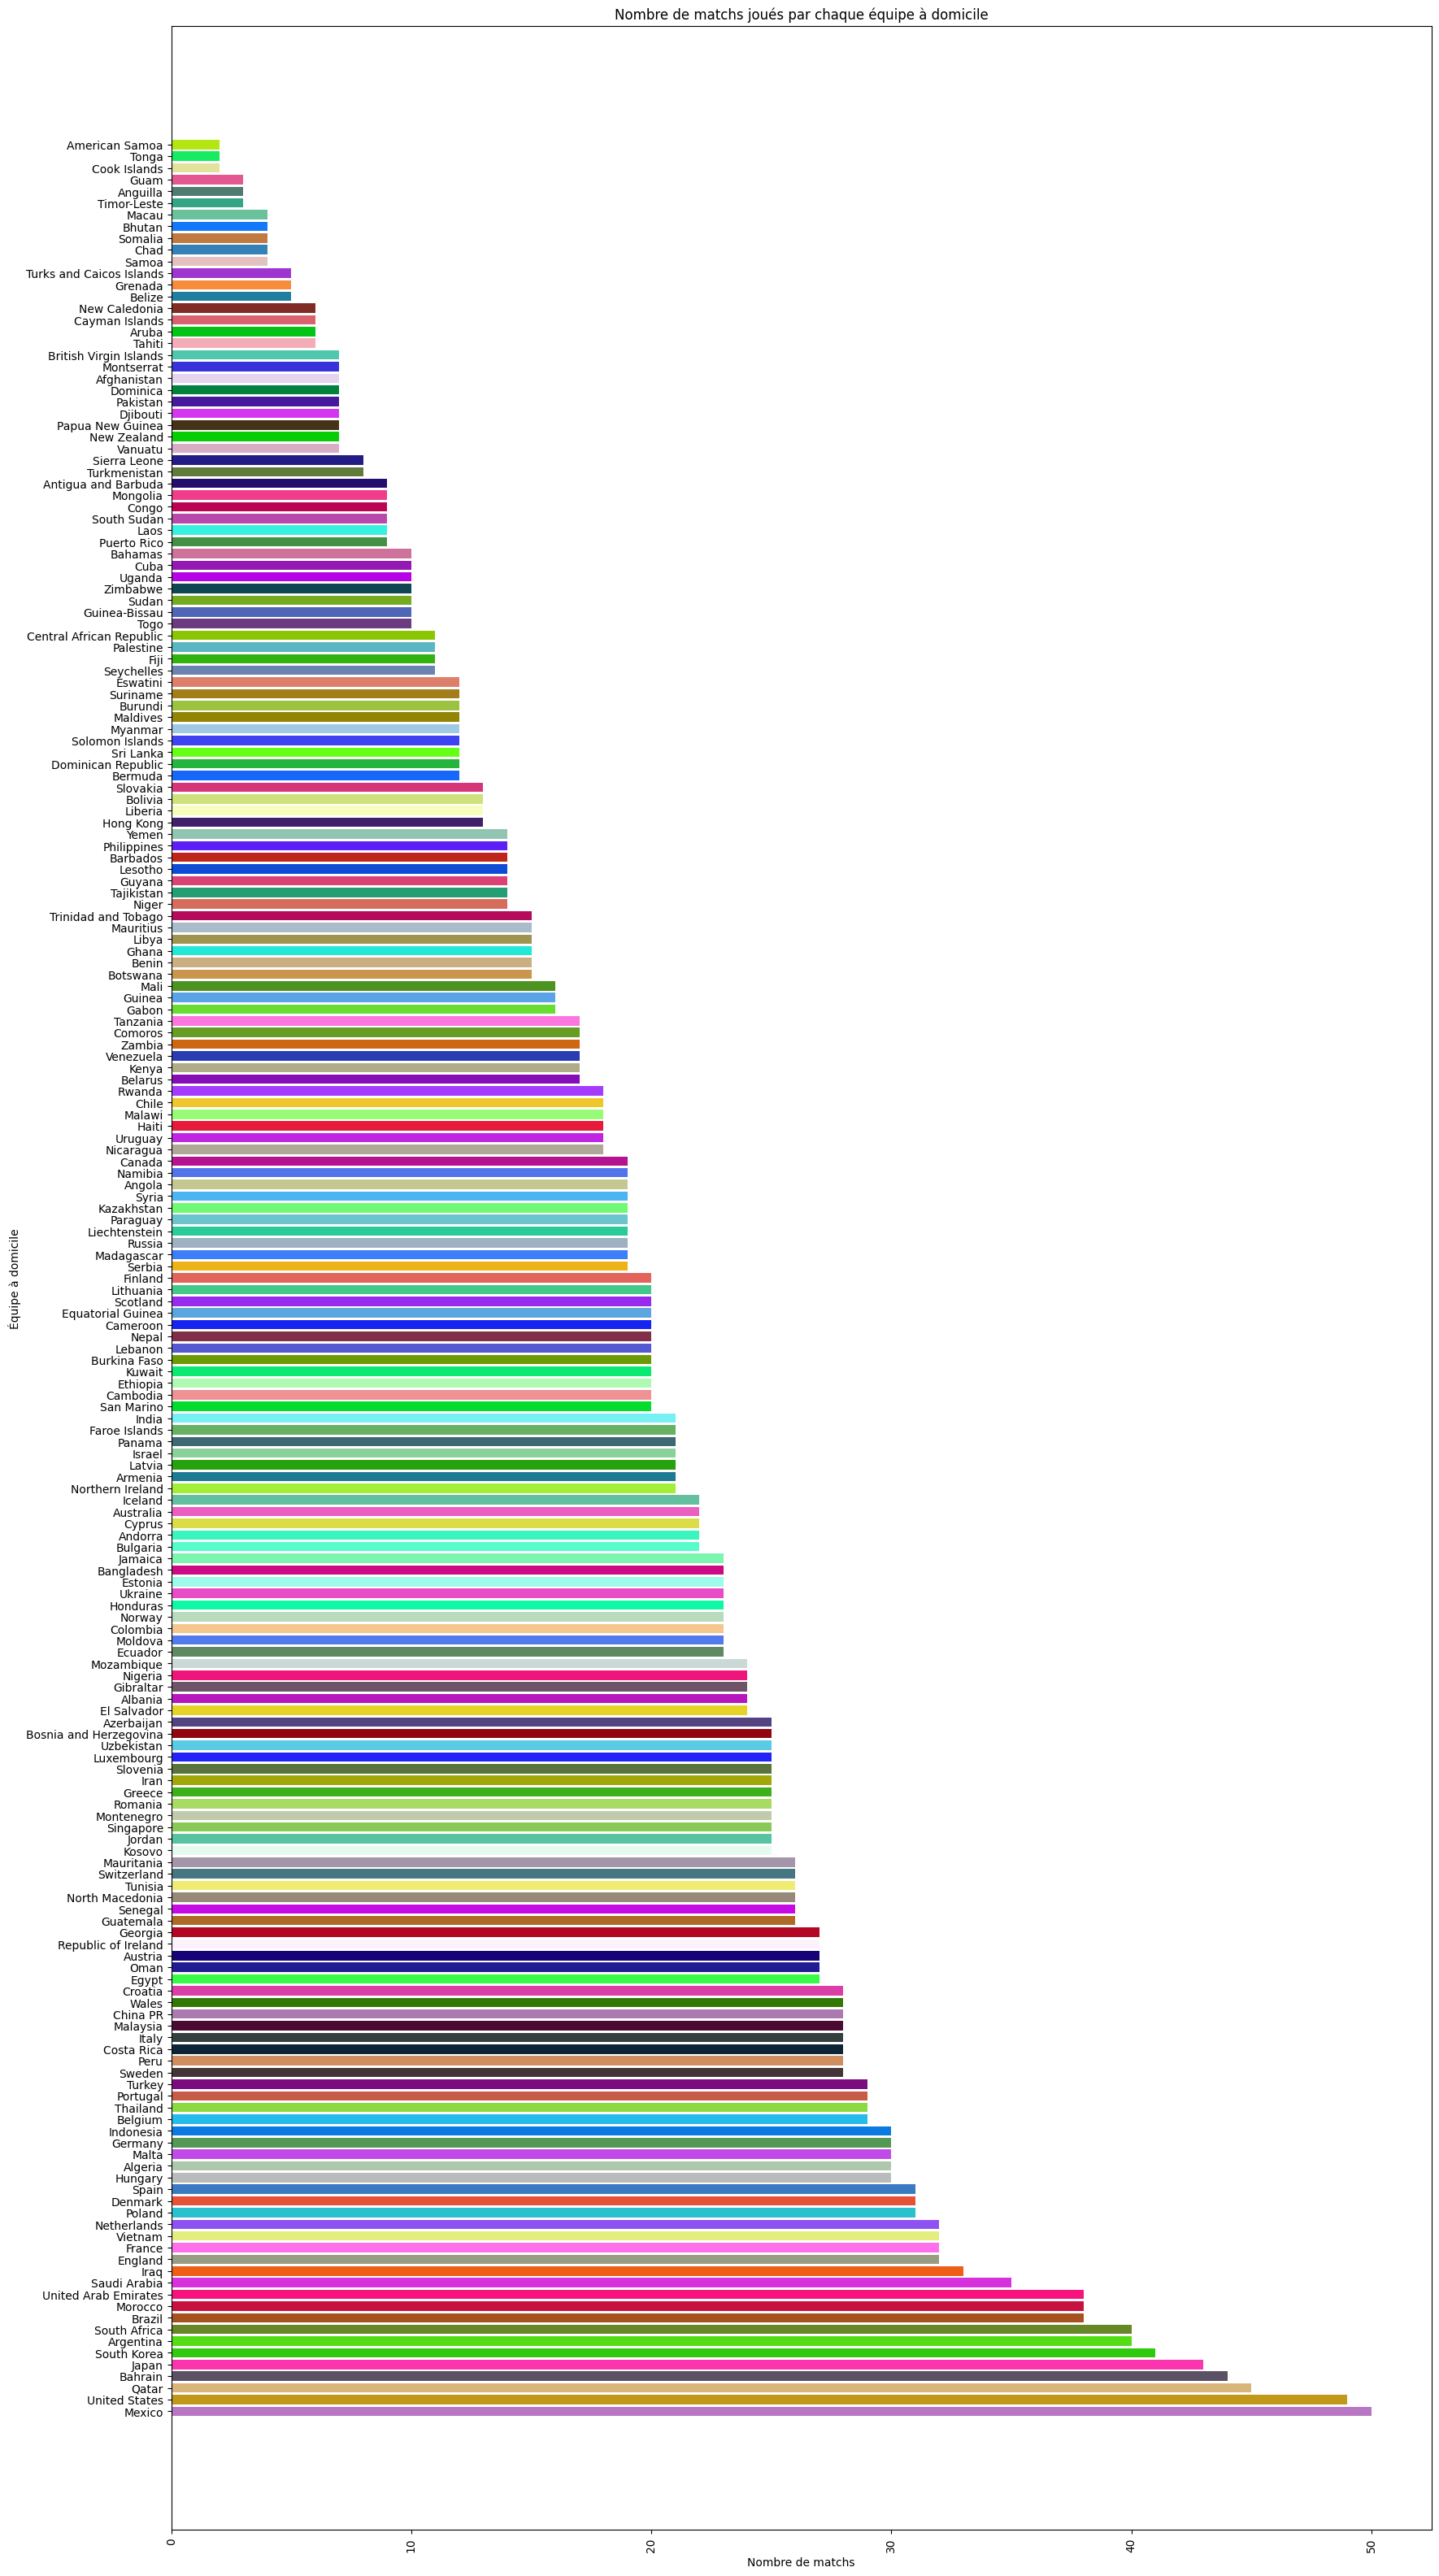

In [451]:
import numpy as np
colors = np.random.rand(df['home_team'].shape[0], 3)
home_team_counts=df['home_team'].value_counts()
plt.figure(figsize=(20, 40))  # Taille du graphique
bars = plt.barh(home_team_counts.index, home_team_counts.values, color=colors)

# Ajouter des labels
plt.xlabel("Nombre de matchs")
plt.ylabel("Équipe à domicile")
plt.title("Nombre de matchs joués par chaque équipe à domicile")
plt.xticks(rotation=90)


# nous utilisons Matplotlib et NumPy pour créer un graphique à barres horizontales  qui montre le nombre de matchs joués par chaque équipe à domicile.
# chaque équipe est sur l'axe Y et le nombre de matchs sur l'axe X, la couleur est différente pour chaque équipe et 
# pour une bonne lisibilité nous avons  ajusté la taille de figure.

#### Mexico et les usa ont jouer plus de match a domicile et le quatar vient en 3e position. en effet ce graphique confirme l'etude de compte de match joues a domicile que nous avons vue plus haut

In [452]:
df.columns

Index(['id', 'date', 'home_team', 'away_team', 'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5', 'target', 'match_type'],
      dtype='object')

(array([ 0.,  5., 10., 15., 20., 25., 30., 35., 40.]),
 [Text(0.0, 0, '0'),
  Text(5.0, 0, '5'),
  Text(10.0, 0, '10'),
  Text(15.0, 0, '15'),
  Text(20.0, 0, '20'),
  Text(25.0, 0, '25'),
  Text(30.0, 0, '30'),
  Text(35.0, 0, '35'),
  Text(40.0, 0, '40')])

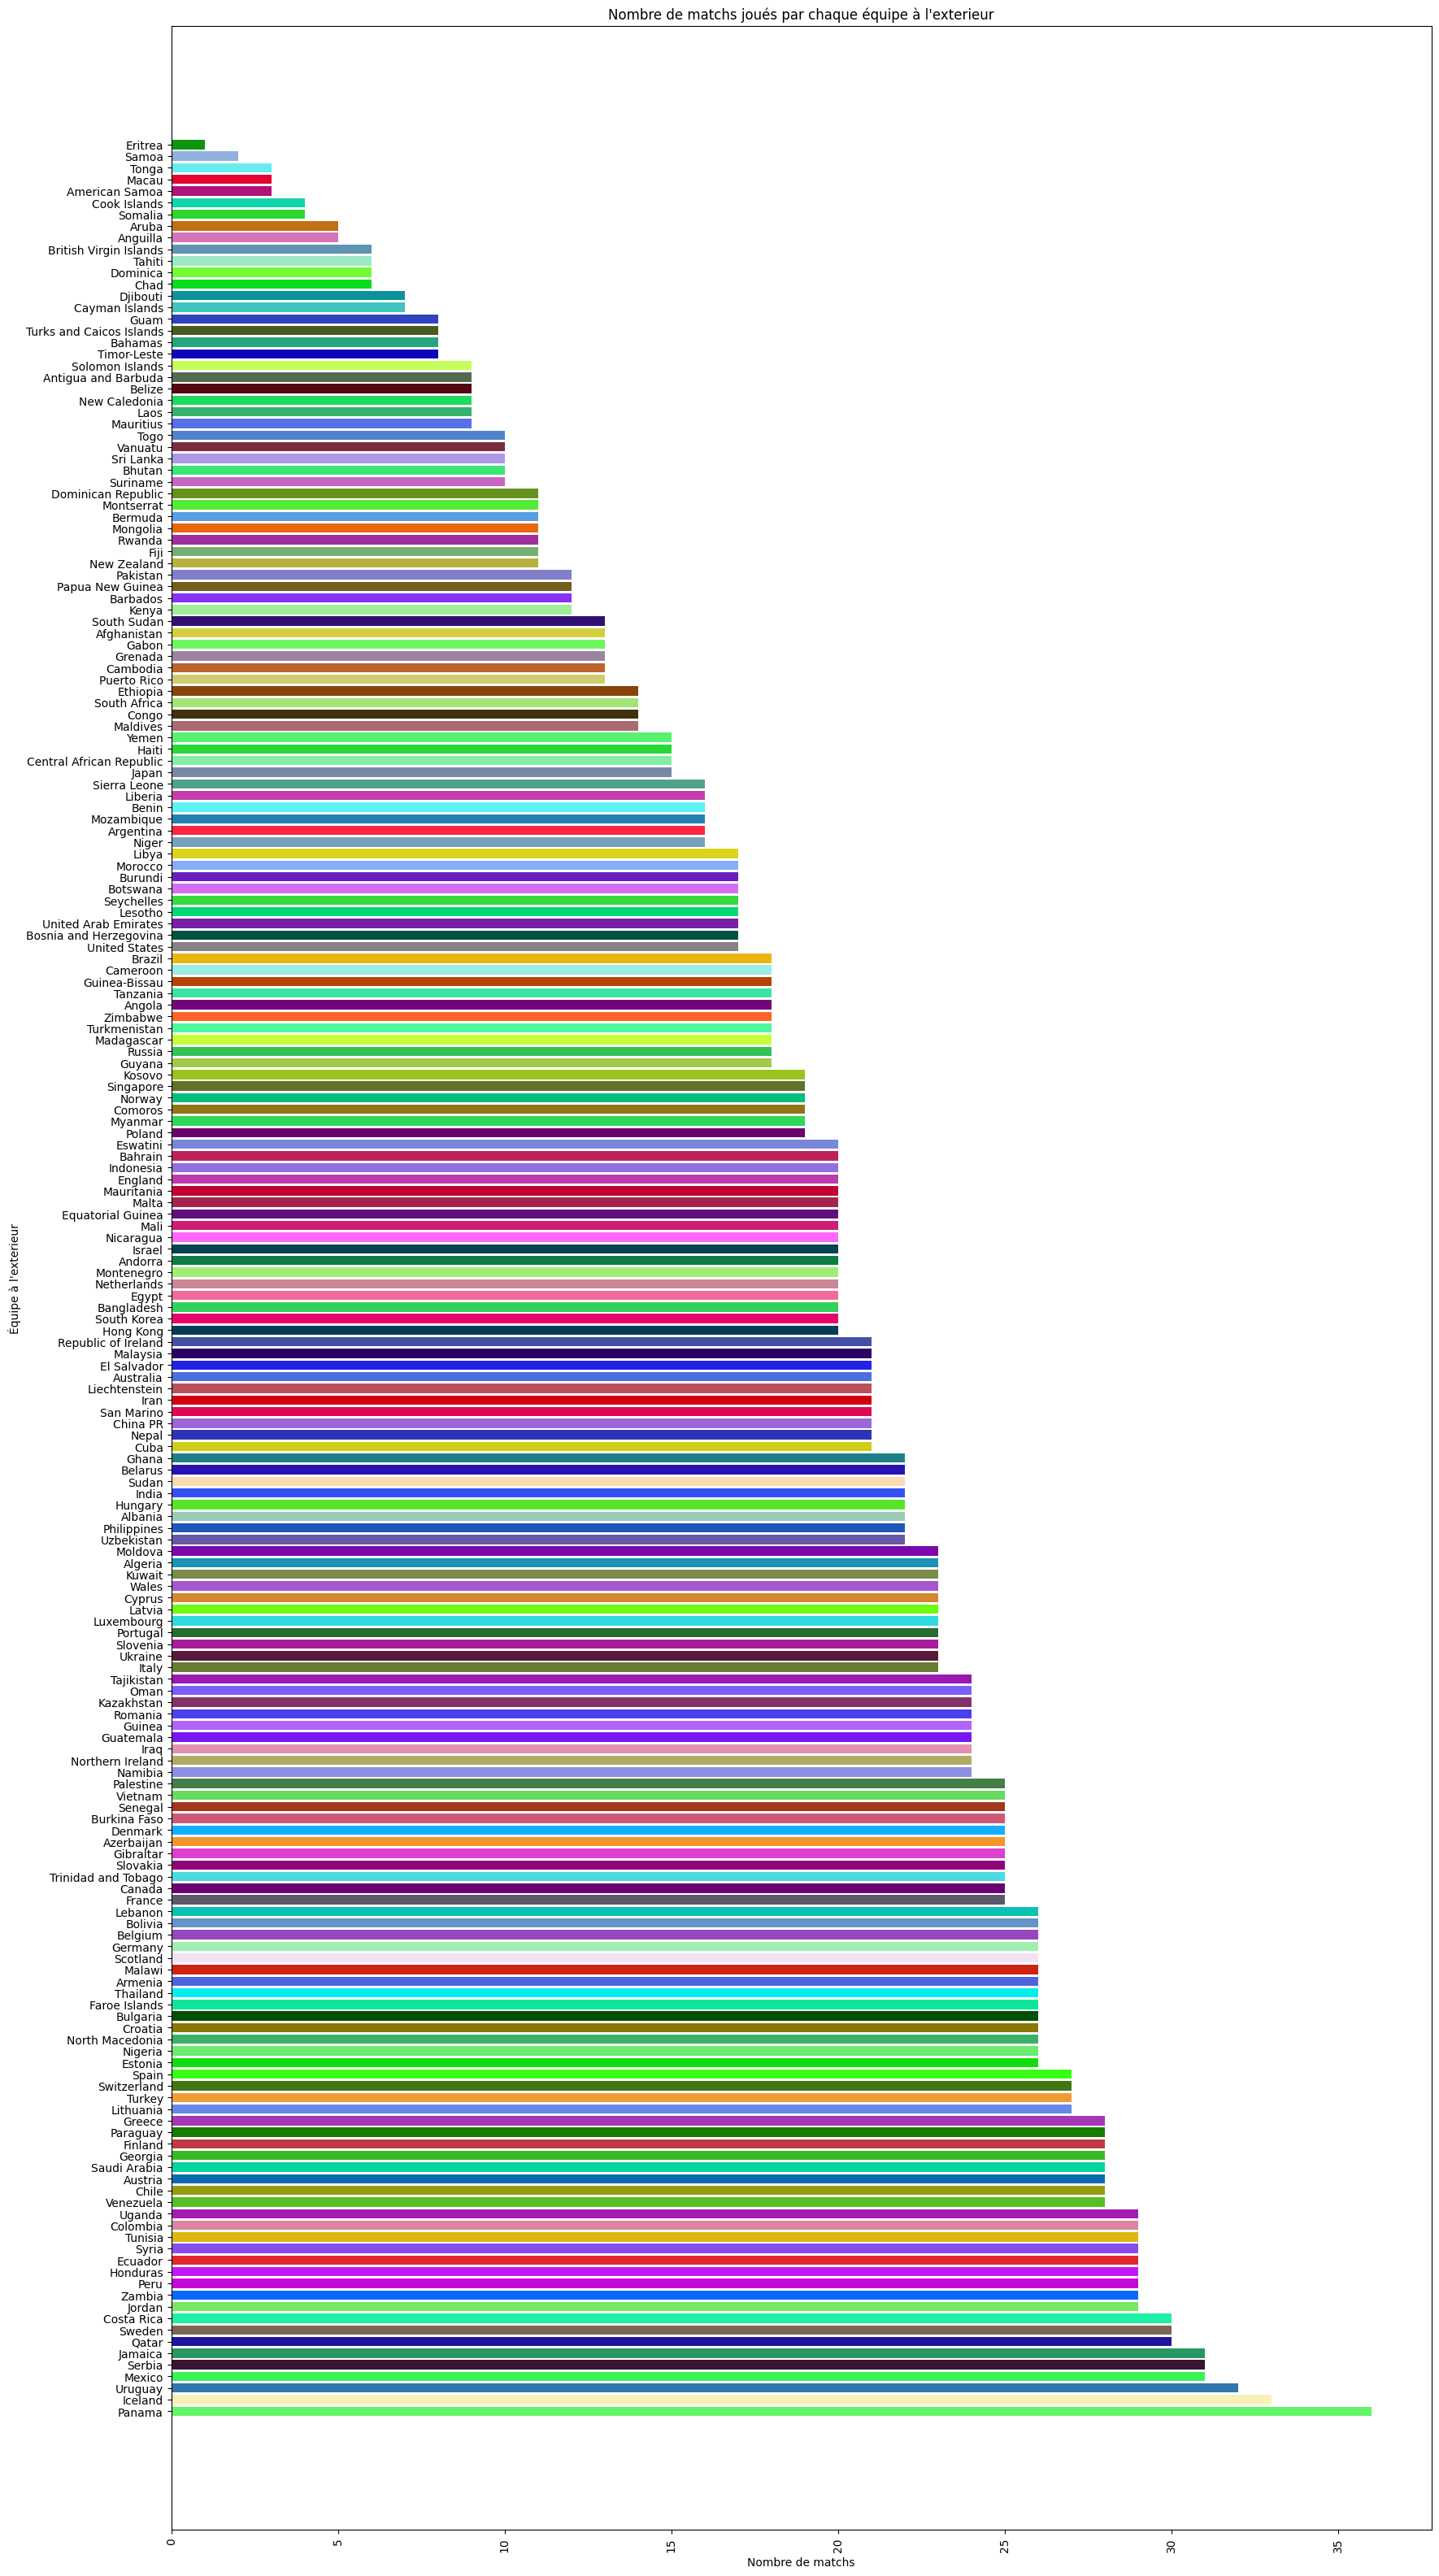

In [453]:
colors = np.random.rand(df['away_team'].shape[0], 3)
away_team_counts=df['away_team'].value_counts()
plt.figure(figsize=(20, 40))  # Taille du graphique
bars = plt.barh(away_team_counts.index, away_team_counts.values, color=colors)

# Ajouter des labels
plt.xlabel("Nombre de matchs")
plt.ylabel("Équipe à l'exterieur")
plt.title("Nombre de matchs joués par chaque équipe à l'exterieur")
plt.xticks(rotation=90)

# nous utilisons Matplotlib et NumPy pour créer un graphique à barres horizontales  qui montre le nombre de matchs joués par chaque équipe à l'exterieur.
# chaque équipe est sur l'axe Y et le nombre de matchs sur l'axe X, la couleur est différente pour chaque équipe et 
# pour une bonne lisibilité nous avons  ajusté la taille de figure.


#### Eritrea et Samoa ont joues tres peu de match a l'exterieur et tonga vient en 3e position. A travers ce graphique nous comptons le nombre de match joues a l'exterieur

## TRAITEMENT DE LA DATE

In [454]:
df_etude=df
df_etude['date']

df_etude['date'] = pd.to_datetime(df['date'])

# Extraction du jour, mois et année
df_etude['jour'] = df['date'].dt.day
df_etude['mois'] = df['date'].dt.month
df_etude['annee'] = df['date'].dt.year

df_etude.groupby('annee')['id'].count().sort_values()

# ici nous manipulons le DataFrame pour extraire les informations temporelles (jour, mois, année) à partir de la colonne date, puis compte le nombre d'occurrences par année.

annee
2020    253
2018    257
2024    347
2023    682
2022    687
2019    724
2021    827
Name: id, dtype: int64

#### Il ya eu plus de match jouer en 2021 et 2019

In [455]:
df_etude.groupby(['annee','target'])['target'].count().sort_values
# nous regroupons  les données par année et par colonne target, puis comptons le nombre d'occurrences de chaque combinaison (annee, target). Enfin, trie les résultats par ordre croissant. 

<bound method Series.sort_values of annee  target
2018   0         136
       1         121
2019   0         350
       1         374
2020   0         108
       1         145
2021   0         396
       1         431
2022   0         335
       1         352
2023   0         306
       1         376
2024   0         170
       1         177
Name: target, dtype: int64>

#### Ces résultats nous donne une vision du nombre de match gagnes et perdu par année selon le target. en 2024 il ya eu 170 matchs gagnes et 177 matchs perdu

In [456]:
df['date'] # Affiche la colonne date du DataFrame df

0      2021-09-09
1      2019-05-29
2      2020-11-18
3      2021-09-01
4      2024-03-22
          ...    
3772   2021-07-12
3773   2019-06-28
3774   2021-10-11
3775   2022-11-19
3776   2022-09-22
Name: date, Length: 3777, dtype: datetime64[ns]

In [457]:
df.columns

Index(['id', 'date', 'home_team', 'away_team', 'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5', 'target', 'match_type',
       'jour', 'mois', 'annee'],
      dtype='object')

### Etude de rank_change_home et rank_change_away

In [458]:
df.groupby('target')['rank_change_home'].mean().sort_values()
# Regroupe les données selon la colonne target (qui peut être une victoire/défaite Pour chaque groupe de target, on calcule la moyenne de la colonne rank_change_home. Enfin, trie les résultats par ordre croissant.

target
0    0.027207
1    0.128036
Name: rank_change_home, dtype: float64

#### Quand target = 0 victoire, Le changement moyen de classement est faible (+0.027).Cela signifie que les victoires ont un faible impact sur l'évolution du classement.

#### Quand target = 1 defaite,Le changement moyen de classement est plus important (+0.128).Cela indique que les défaites entraînent des modifications plus importantes dans le classement.

In [459]:
df.groupby('target')['rank_change_away'].mean().sort_values()
# nous voulons maintenant analyser l'impact des victoires et défaites sur le classement des équipes à l'extérieur (rank_change_away).
# regroupe les données par la colonne target, puis calcule la moyenne de la colonne rank_change_away pour chaque groupe. Enfin, trie les résultats par ordre croissant

target
0    0.039024
1    0.045902
Name: rank_change_away, dtype: float64

#### Les équipes qui gagnent a l'exterieur (target = 0), leur classement évolue en moyenne de +0.039. Cela signifie qu’une victoire à l'extérieur améliore légèrement le classement.

#### Les équipes qui perdent a l'exterieur (target = 1), leur classement évolue en moyenne de +0.045. La défaite impacte plus le classement que la victoire, mais l’écart est faible (0.039 vs 0.045).


Text(0, 0.5, 'rank_change_home')

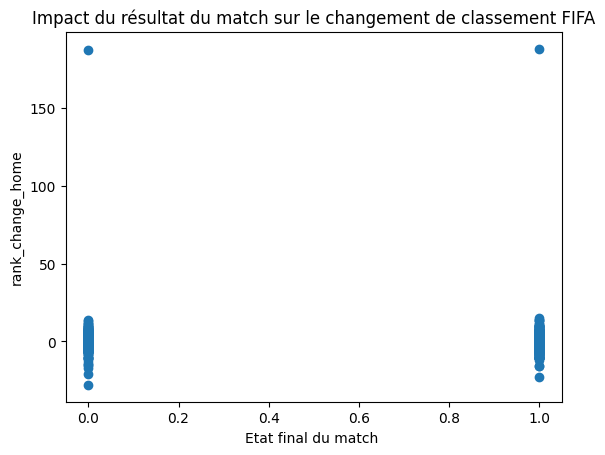

In [460]:
plt.scatter(df['target'],df['rank_change_home'])
plt.title("Impact du résultat du match sur le changement de classement FIFA")
plt.xlabel('Etat final du match ')
plt.ylabel('rank_change_home')

# créer un nuage de points (scatter plot) qui montre la relation entre le target et rank_change_home


#### si rank change est positif signifie que l'equipe a progresser et si il a un rank change negatif cela veut dire qu'il a regresser. La majorité des valeurs sont proches de zéro. Quelques valeurs extrêmes dépassent 150+, ce qui indique de rares matchs avec un fort impact sur le classement FIFA.

### Etude de home_goals_mean et home_goals_mean_l5

In [461]:
df.groupby('target')['home_goals_mean'].mean().sort_values()
# regroupe les données par la colonne target, puis calcule la moyenne de la colonne home_goals_mean pour chaque groupe. Enfin, trie les résultats par ordre croissant.

target
1    1.239102
0    1.500976
Name: home_goals_mean, dtype: float64

#### Les équipes à domicile marquent en moyenne plus de buts quand elles gagnent.

In [462]:
df.groupby('target')['home_goals_mean_l5'].mean().sort_values()
# regroupe les données par la colonne target, puis calcule la moyenne de la colonne home_goals_mean_l5 pour chaque groupe. Enfin, trie les résultats par ordre croissant.

target
1    1.209059
0    1.519286
Name: home_goals_mean_l5, dtype: float64

#### les equipes qui ont plus marquer de but dans les matchs precedent comme les 5 derniers matchs prcendents ont plus de chance de gagner le match actuel

### Etude de away_goals_mean et away_goals_mean_l5

In [463]:
df.groupby('target')['away_goals_mean'].mean().sort_values()
#  regrouper les données par la colonne target, puis calcule la moyenne de la colonne away_goals_mean pour chaque groupe. Enfin, trie les résultats par ordre croissant.

target
0    1.188358
1    1.412561
Name: away_goals_mean, dtype: float64

#### Les équipes qui gagnent à domicile (target = 0) ont un away_goals_mean de 1.188. Les équipes qui perdent à domicile affrontent souvent des adversaires plus offensifs à l'extérieur.

In [464]:
df.groupby('target')['away_goals_mean_l5'].mean().sort_values()
#  regroupe les données par la colonne target, puis calcule la moyenne de la colonne away_goals_mean_l5 pour chaque groupe. Enfin, trie les résultats par ordre croissant

target
0    1.155627
1    1.439145
Name: away_goals_mean_l5, dtype: float64

#### Si une équipe a marqué beaucoup de buts lors de ses 5 derniers matchs à l'extérieur, elle a plus de chances de gagner son prochain match à l'extérieur.

In [465]:
df.groupby('target')['home_goals_suf_mean'].mean().sort_values()
# regroupe les données par la colonne target, puis calcule la moyenne de la colonne home_goals_suf_mean pour chaque groupe. Enfin, trie les résultats par ordre croissant.

target
0    1.102528
1    1.385734
Name: home_goals_suf_mean, dtype: float64

####  Les équipes qui encaissent moins de buts à domicile ont plus de chances de gagner.

In [466]:
df.groupby('target')['home_goals_suf_mean_l5'].mean().sort_values()
#  regroupe les données par la colonne target, puis calcule la moyenne de la colonne home_goals_suf_mean_l5 pour chaque groupe. Enfin, trie les résultats par ordre croissant.

target
0    1.101610
1    1.463192
Name: home_goals_suf_mean_l5, dtype: float64

#### Une équipe qui a encaissé beaucoup de buts lors de ses 5 derniers matchs à domicile a plus de risques de perdre.

In [467]:
df.groupby('target')['away_goals_suf_mean'].mean().sort_values()
# regroupe les données par la colonne target, puis calcule la moyenne de la colonne away_goals_suf_mean pour chaque groupe. Enfin, trie les résultats par ordre croissant.

target
1    1.182519
0    1.471440
Name: away_goals_suf_mean, dtype: float64

#### Les équipes qui gagnent à domicile encaissent plus de buts en moyenne lorsqu'elles jouent à l'extérieur.

In [468]:
df.groupby('target')['away_goals_suf_mean_l5'].mean().sort_values()
# regroupe les données par la colonne target, puis calcule la moyenne de la colonne away_goals_suf_mean pour chaque groupe. Enfin, trie les résultats par ordre croissant

target
1    1.186682
0    1.516185
Name: away_goals_suf_mean_l5, dtype: float64

#### Les équipes qui gagnent à domicile encaissent généralement plus de buts en déplacement, ce qui pourrait indiquer une dépendance au jeu à domicile.

In [469]:
df.groupby('target')['away_rank_mean'].mean().sort_values()
#  regroupe les données par la colonne target, puis calcule la moyenne de la colonne away_rank_mean pour chaque groupe. Enfin, trie les résultats par ordre croissant.

target
1    82.680140
0    94.039627
Name: away_rank_mean, dtype: float64

####  Les équipes a l'exterieur qui gagnent sont en moyenne mieux classées que celles qui perdent. Une équipe avec un mauvais classement FIFA a plus de chances de perdre. nous pouvons tirer comme conclusion que le classement est un bon indicateur pour prédire la performance d’une équipe à l'extérieur.

match_type

In [470]:
df['match_type'].value_counts()
# Nous comptons ici le nombre de match amicaux et competition

match_type
Friendly       2709
Competition    1068
Name: count, dtype: int64

#### il y'a eu au total 2709 match amicaux et 1068 matchs competition

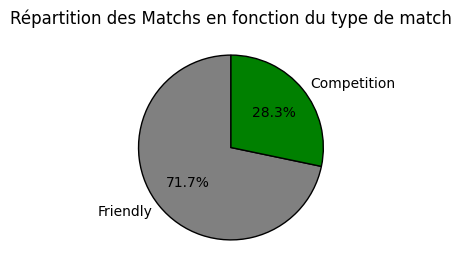

In [ ]:
valu = df['match_type'].value_counts()


# Définition des couleurs
colors = ['gray', 'green'] 
plt.figure(figsize=(3, 3))
plt.pie(valu.values, labels=valu.index, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})

# Ajouter un titre
plt.title("Répartition des Matchs en fonction du type de match")

# Afficher le graphique
plt.show()


#### Nous avons representer les match que nous avons compter plus haut et cela confirme notre compte. plus de match amical soit 71.7% que de match de competition soit 28.3%

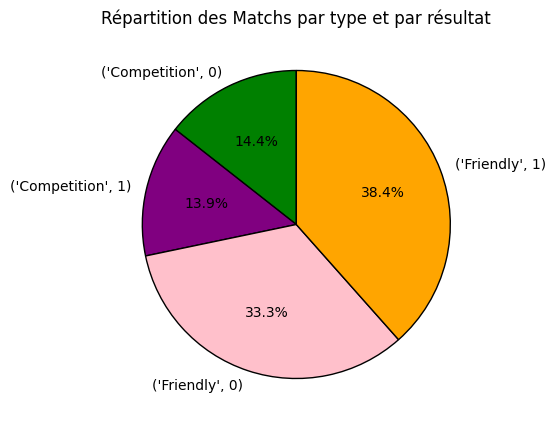

In [472]:
match_ty_tag=df.groupby(['match_type','target'])['id'].count()

# Définition des couleurs
colors = ['green', 'purple','pink','orange'] 
plt.figure(figsize=(5, 5))
plt.pie(match_ty_tag.values, labels=match_ty_tag.index, autopct='%1.1f%%', colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})

# titre de la figure
plt.title("Répartition des Matchs par type et par résultat")

# montrer le graphique (afficher)
plt.show()

#### on a plus de match amicaux toujour et  Les équipes à domicile perdent plus souvent lors des matchs amicaux. Les compétitions sont plus équilibrées entre victoires et défaites.

In [473]:
df['target'].value_counts()
# nous comptons ici le nombre de victoires et de defaite

target
1    1976
0    1801
Name: count, dtype: int64

On remarque qu'on a plus de défaite ou match nul pour l'équipe à domicile que de victoire
On remarque également que les données ne sont pas trop imbalancées dans l'utilisation des méthodes de stratification est optionelle.

In [474]:
df.groupby('target')['match_type'].count().sort_values()
# compte le nombre de matchs pour chaque type de résultat

target
0    1801
1    1976
Name: match_type, dtype: int64

#### Les défaites à domicile sont plus nombreuses que les victoires 1976 défaites contre 1801 victoires.

In [475]:
df['target'].isna().sum()
# permet de vérifier s'il y a des valeurs manquantes dans la colonne target

np.int64(0)

#### il n'y a pas de valeur manquante dans la colone target

<Axes: >

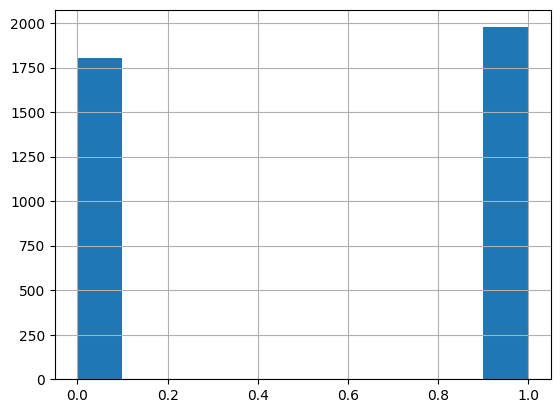

In [476]:
df['target'].hist()
# nous tracons ici un histogramme de l,ensembles des resultat des match

#### Nombre de défaites légèrement supérieur aux victoires, cela confirme que les équipes à domicile ne gagnent pas systématiquement.

### Correlation entre les caractéristiques et le Target

In [477]:
list=[  'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5','target']

In [478]:
matrice=df[list].corr()
matrice
# La matrice de corrélation va nous permettre de mesurer la relation entre chaque caractéristique et la variable target (victoire ou défaite de l’équipe à domicile).

,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,home_rank_mean_l5,home_points_mean,home_points_mean_l5,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,target
rank_change_home,1.000000,0.004360,-0.053333,-0.068907,0.184347,0.196897,0.018259,0.011341,-0.068257,-0.127510,-0.037754,-0.021917,0.116498,0.103648,0.036201,0.029399,-0.004791,-0.004786,0.010092
rank_change_away,0.004360,1.000000,-0.002664,0.022764,0.009075,0.023530,-0.025877,-0.026186,-0.014871,-0.018654,-0.044334,-0.123231,0.029945,0.128464,-0.036786,-0.045497,-0.111740,-0.272870,0.001414
home_goals_mean,-0.053333,-0.002664,1.000000,0.738638,-0.491231,-0.411112,-0.149951,-0.122543,0.520273,0.258491,0.161189,0.099609,-0.087837,-0.063520,-0.103305,-0.115975,0.104940,0.035337,-0.216160
home_goals_mean_l5,-0.068907,0.022764,0.738638,1.000000,-0.360055,-0.397609,-0.106621,0.092537,0.363166,0.309890,0.114170,0.111044,-0.046105,-0.041434,-0.036735,-0.010950,0.050790,0.017738,-0.185658
home_goals_suf_mean,0.184347,0.009075,-0.491231,-0.360055,1.000000,0.805046,0.260853,0.234292,-0.416072,-0.243689,-0.050621,-0.028098,0.244178,0.185383,0.185849,0.187223,-0.099418,-0.037734,0.206985
home_goals_suf_mean_l5,0.196897,0.023530,-0.411112,-0.397609,0.805046,1.000000,0.209621,0.049084,-0.321602,-0.329674,-0.045450,-0.035095,0.177237,0.165575,0.125514,0.107442,-0.061845,-0.018120,0.208255
home_rank_mean,0.018259,-0.025877,-0.149951,-0.106621,0.260853,0.209621,1.000000,0.859086,-0.227598,-0.099269,-0.121211,-0.059617,0.216219,0.166117,0.664667,0.626579,-0.097963,-0.046778,0.113817
home_rank_mean_l5,0.011341,-0.026186,-0.122543,0.092537,0.234292,0.049084,0.859086,1.000000,-0.219425,-0.076141,-0.116707,-0.032085,0.210947,0.138611,0.606530,0.610708,-0.119190,-0.047298,0.074417
home_points_mean,-0.068257,-0.014871,0.520273,0.363166,-0.416072,-0.321602,-0.227598,-0.219425,1.000000,0.423936,0.080397,0.018092,-0.115926,-0.081580,-0.117901,-0.138570,0.124286,0.017301,-0.170648
home_points_mean_l5,-0.127510,-0.018654,0.258491,0.309890,-0.243689,-0.329674,-0.099269,-0.076141,0.423936,1.000000,0.029587,0.016103,-0.051180,-0.044428,-0.061053,-0.048329,0.018330,0.002118,-0.110375


#### home_goals_suf_mean_l5: plus le nombre de but encaissé par l'équipe à domicile augmente plus elle risque de perdre le match. lorsque cest 0 l'equipe a gagne, quand cest 1 l'equipe a perdu.lorsque le nombre de but encaisse a dommicile est beaucoup, l'etiquette augmente aussi.si la  carracterristique augmente le target augmente, et contraire pour l'autre


<Axes: >

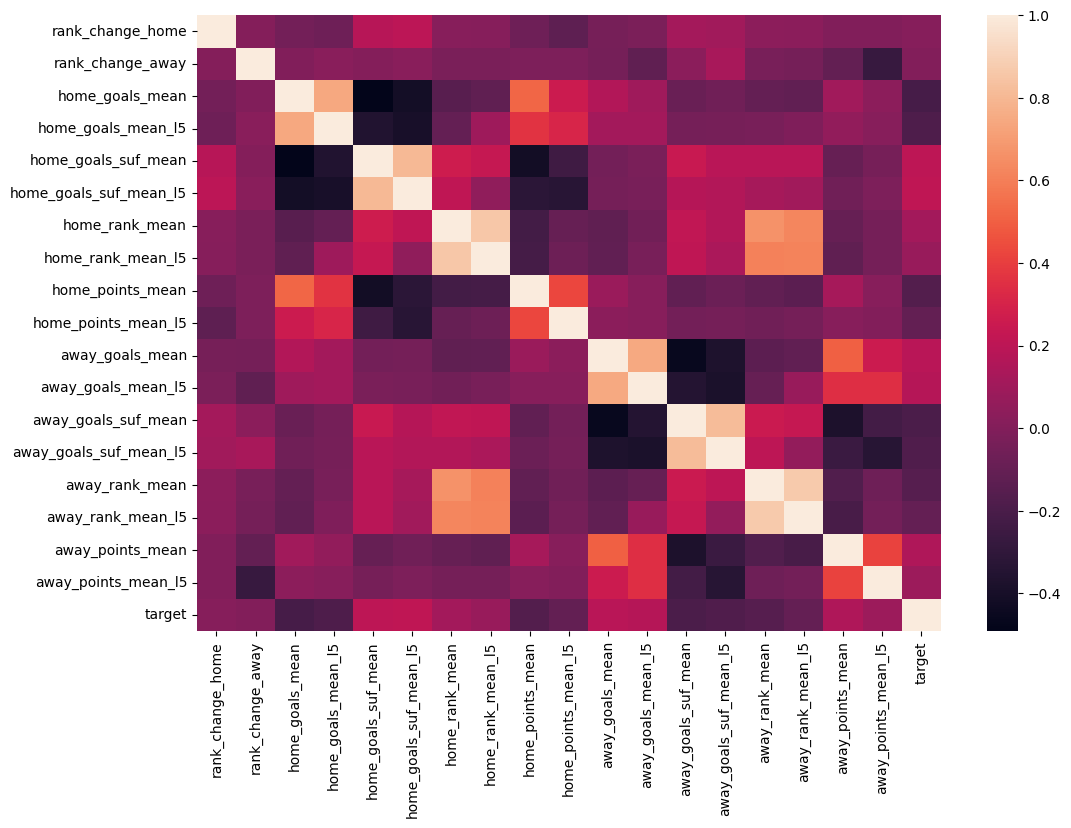

In [479]:
import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(matrice)
# nous representons graphiquement notre matrice.

#### Les valeurs les plus claires indiquent les caractéristiques les plus corrélées avec target Les valeurs proches de 1 ou -1 indiquent une forte relation avec target.Les cases plus sombres indiquent une faible ou aucune corrélation.Certaines caractéristiques sont fortement liées entre elles (zones claires hors de la diagonale). comme par exemple
#### home_rank_mean et home_rank_mean_l5, away_rank_mean et away_rank_mean_l5

 #### Cela montre que le classement récent et moyen d'une équipe sont fortement liés.

In [594]:
import pandas as pd
df = pd.read_csv("football.csv") 

competition=pd.read_csv("competition.csv")
competition_base=pd.read_csv("competition.csv")
#Nous avons charger les donnees du fichier football.csv.|

In [595]:
competition.columns

Index(['id', 'date', 'home_team', 'away_team', 'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5', 'match_type'],
      dtype='object')

#### competition.csv contient les meme colones que football.csv sauf le target

# Prétraitement de données

## Traitement des valeurs aberantes

afin de bien identifier les donnes aberantes nous allons utiliser la boite a moustache

<Axes: >

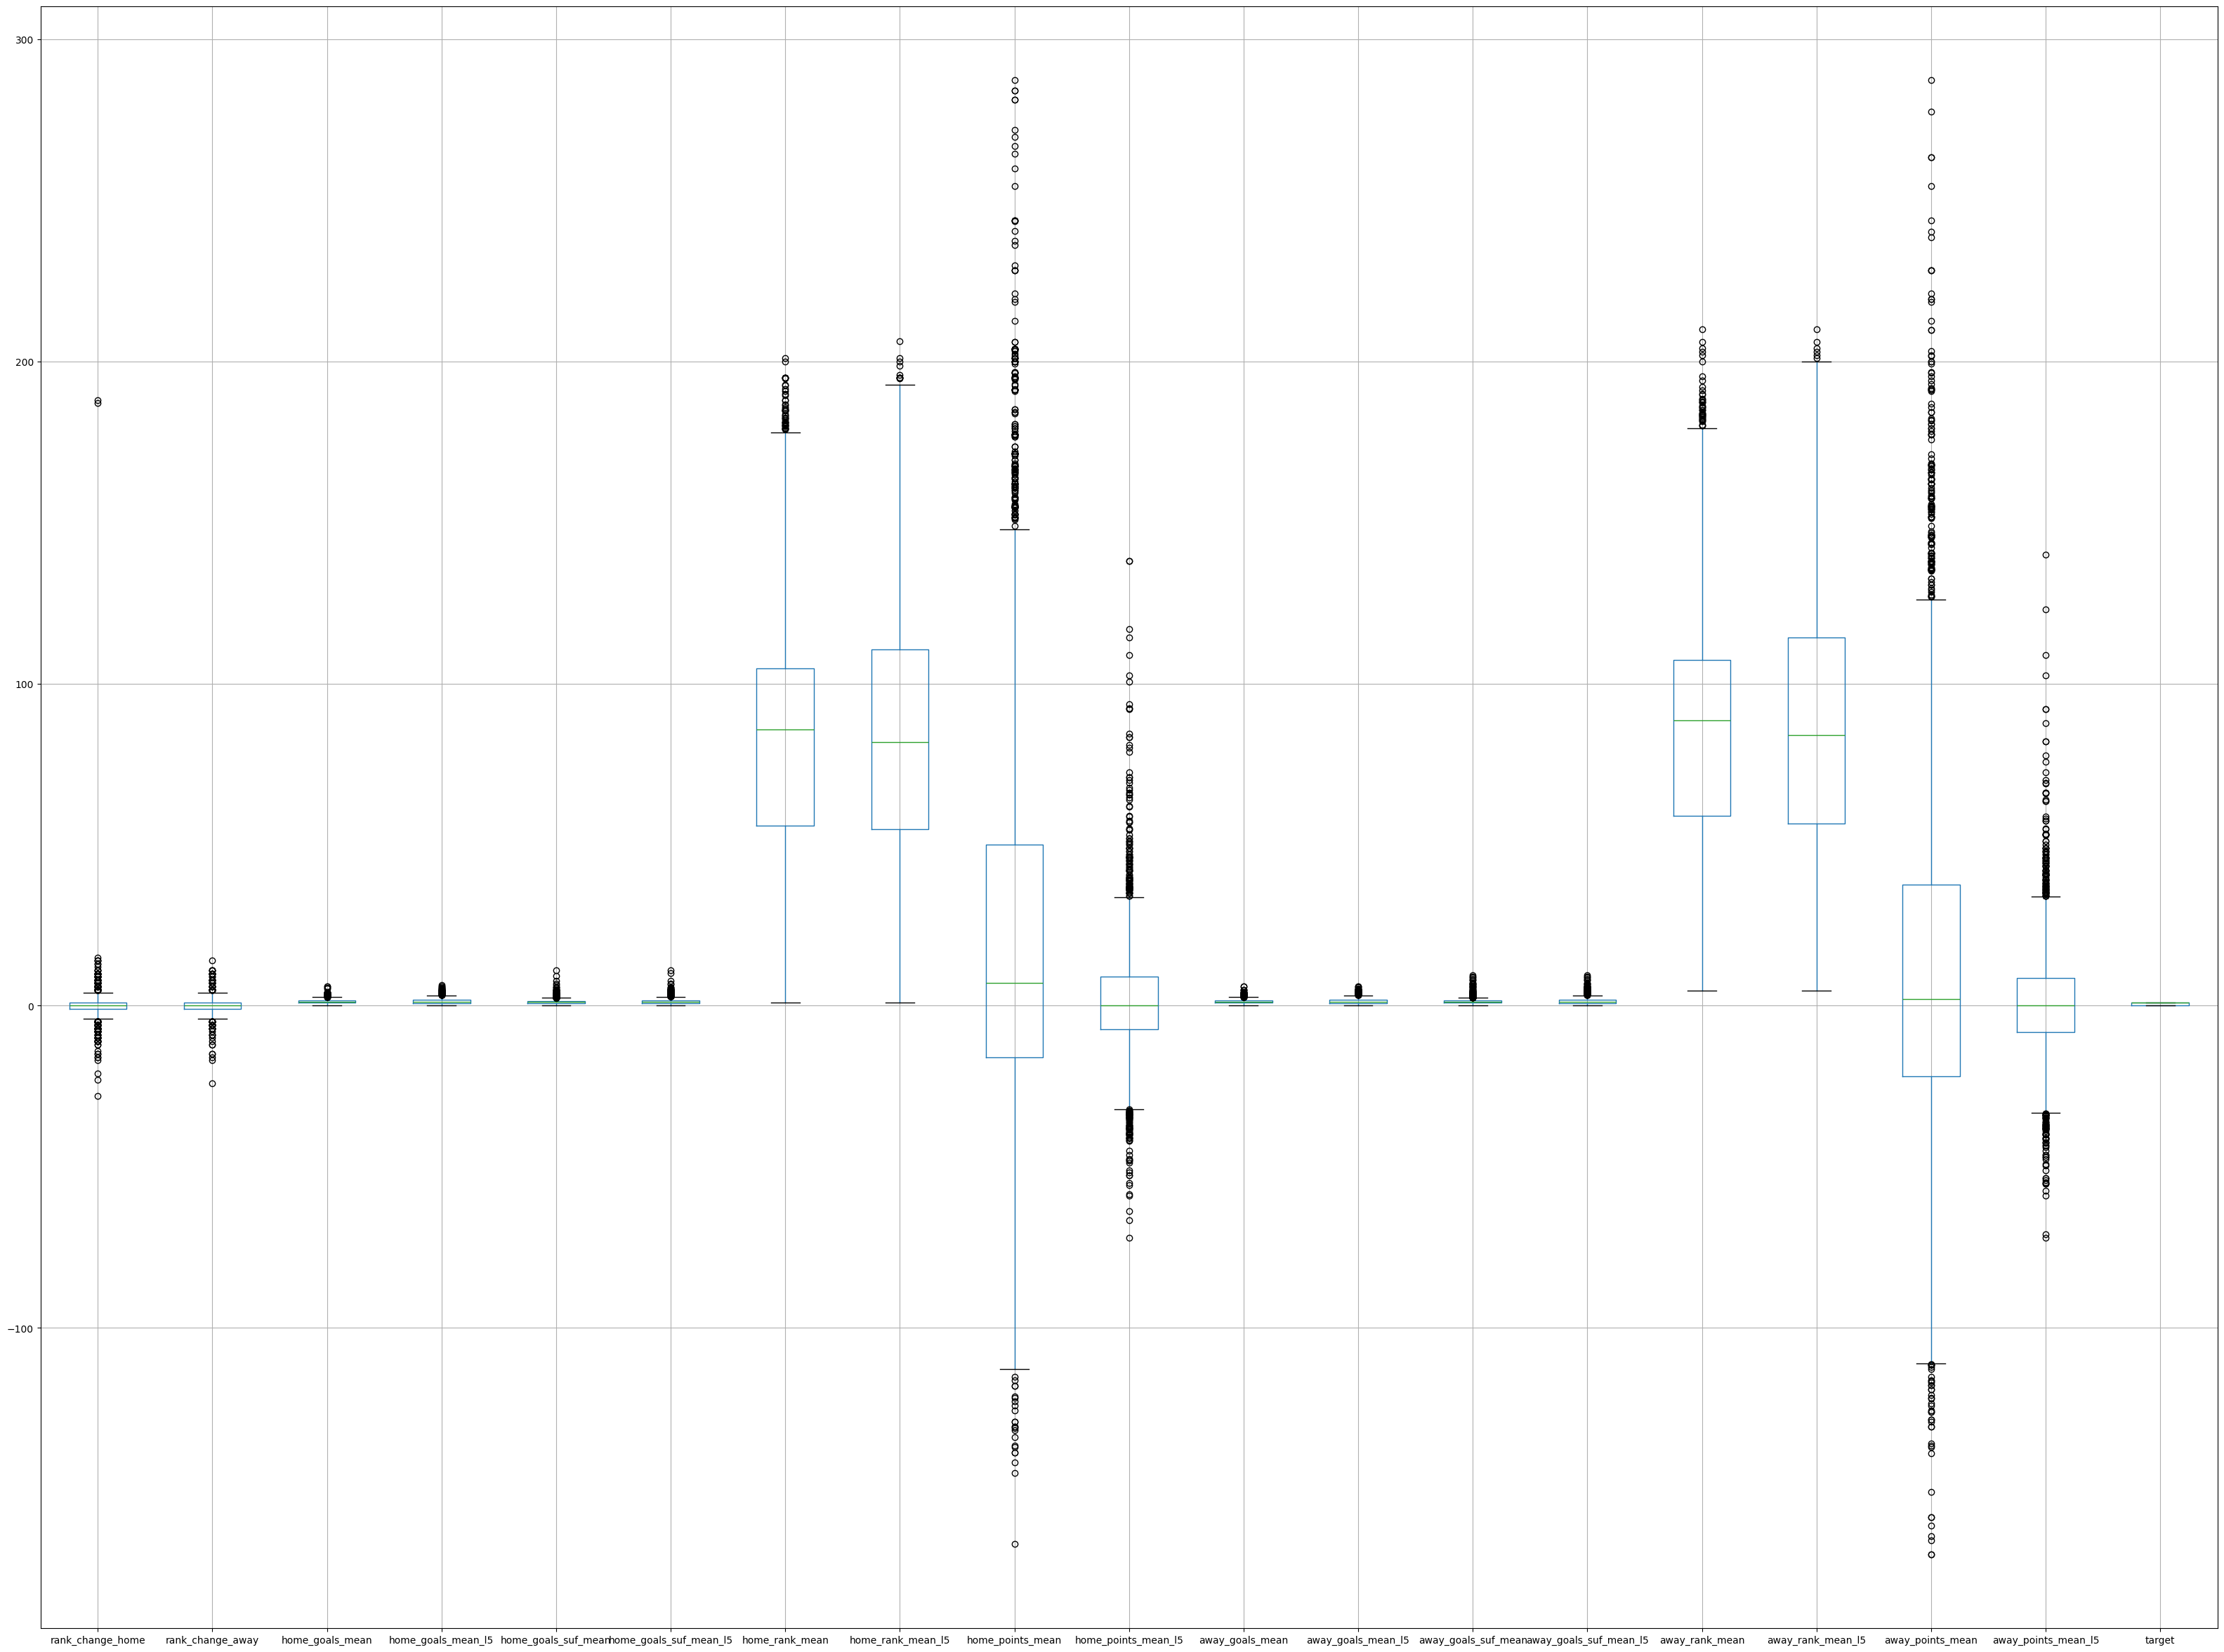

In [596]:
list= [ 'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5', 'target', 'match_type']
df[list].boxplot(figsize=(40, 30))

In [597]:
list

['rank_change_home',
 'rank_change_away',
 'home_goals_mean',
 'home_goals_mean_l5',
 'home_goals_suf_mean',
 'home_goals_suf_mean_l5',
 'home_rank_mean',
 'home_rank_mean_l5',
 'home_points_mean',
 'home_points_mean_l5',
 'away_goals_mean',
 'away_goals_mean_l5',
 'away_goals_suf_mean',
 'away_goals_suf_mean_l5',
 'away_rank_mean',
 'away_rank_mean_l5',
 'away_points_mean',
 'away_points_mean_l5',
 'target',
 'match_type']

nous remarquons que 

In [598]:
list1= ['rank_change_home','rank_change_away','home_points_mean_l5','away_points_mean_l5']

rank_change_home','rank_change_away','home_points_mean_l5','away_points_mean_l5       ces colones presentent beaucoup des donnees aberantes qui compressent la boite a moustache. Nous allons donc plus les etudier davantage

In [599]:
list2= ['home_rank_mean','home_rank_mean_l5','home_points_mean','away_rank_mean','away_rank_mean_l5','away_points_mean']

Ces caracteristiques presentent beaucoup de valeurs aberantes mais presentent une grande dispersion des donnees 

<Axes: >

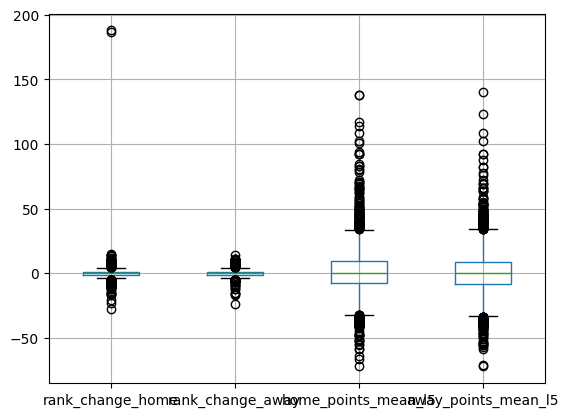

In [600]:
list1= ['rank_change_home','rank_change_away','home_points_mean_l5','away_points_mean_l5']
df[list1].boxplot()

In [601]:
rda = df
#copie de DataFrame pour les etude

## rank_change_home

In [602]:
rda['rank_change_home'].describe()

count    3777.000000
mean        0.079958
std         4.990718
min       -28.000000
25%        -1.000000
50%         0.000000
75%         1.000000
max       188.000000
Name: rank_change_home, dtype: float64

<Axes: >

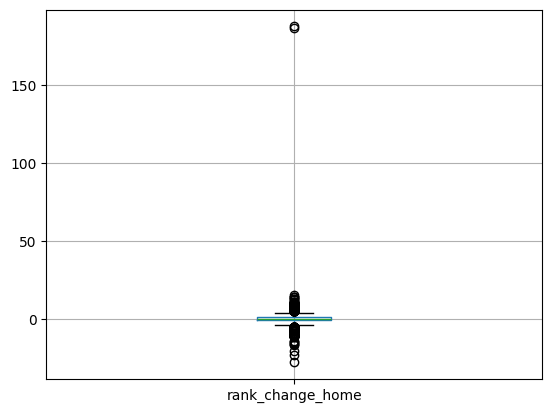

In [603]:
rda[['rank_change_home']].boxplot()

In [604]:
rda[rda ["rank_change_home"] < -8].shape


(32, 24)

In [605]:
rda = rda[((rda["rank_change_home"] < 8) & (rda["rank_change_home"] > -8)) | (rda['rank_change_home'].isna())]

<Axes: >

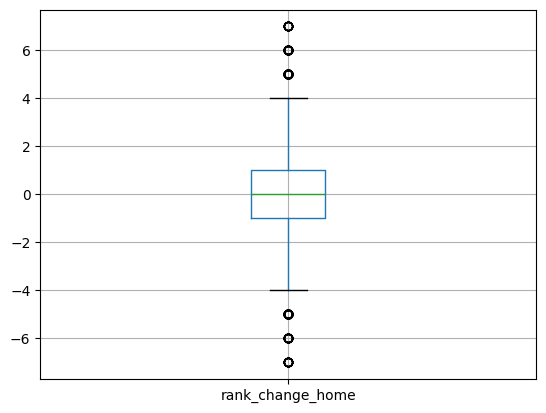

In [606]:
rda[['rank_change_home']].boxplot()

In [607]:
rda.shape

(3700, 24)

# rank_change_away

<Axes: >

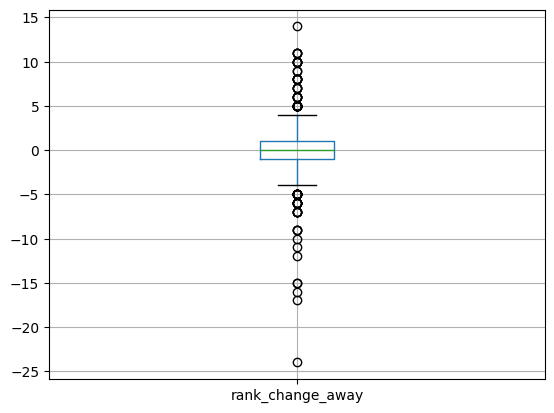

In [608]:
rda[['rank_change_away']].boxplot()

In [609]:
rda[rda ["rank_change_away"] < -15].shape

(3, 24)

In [610]:
rda = rda[((rda["rank_change_away"] < 10) & (rda["rank_change_away"] > -10) )| (rda['rank_change_away'].isna())]

In [611]:
rda.shape

(3681, 24)

<Axes: >

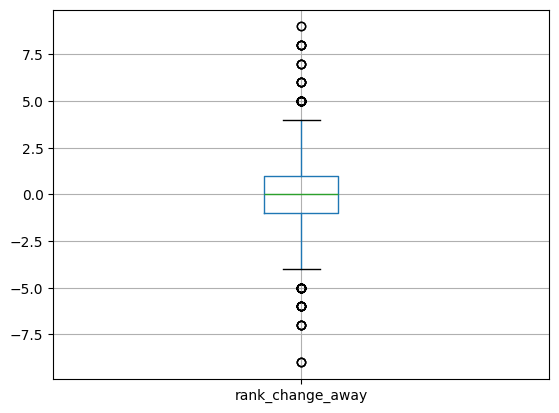

In [612]:
rda[['rank_change_away']].boxplot()

<Axes: >

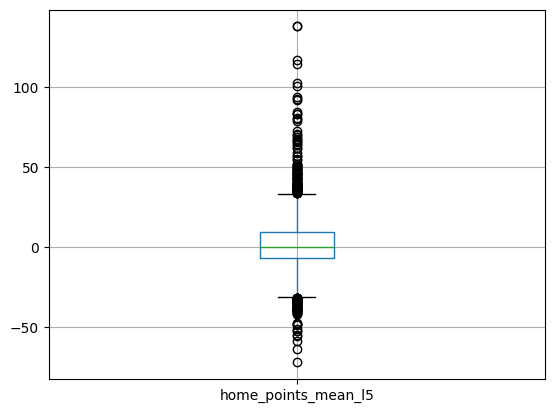

In [613]:
rda[['home_points_mean_l5']].boxplot()

In [614]:
rda[rda ["home_points_mean_l5"] < -50].shape

(8, 24)

In [615]:
rda = rda[((rda["home_points_mean_l5"] < 50) & (rda["home_points_mean_l5"] > -50)) | (rda['home_points_mean_l5'].isna())]


<Axes: >

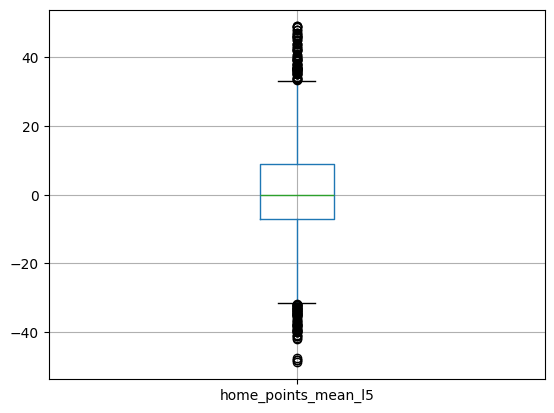

In [616]:
rda[['home_points_mean_l5']].boxplot()

In [617]:
rda.shape

(3634, 24)

<Axes: >

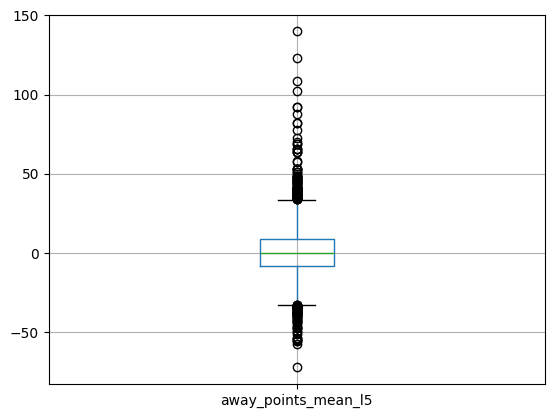

In [618]:
rda[['away_points_mean_l5']].boxplot()

In [619]:
rda[rda ["away_points_mean_l5"] > 60].shape

(20, 24)

In [620]:
rda[rda ["away_points_mean_l5"] < -50].shape

(9, 24)

In [621]:
rda = rda[((rda["away_points_mean_l5"] < 50) & (rda["away_points_mean_l5"] > -50))  | (rda['away_points_mean_l5'].isna())]

<Axes: >

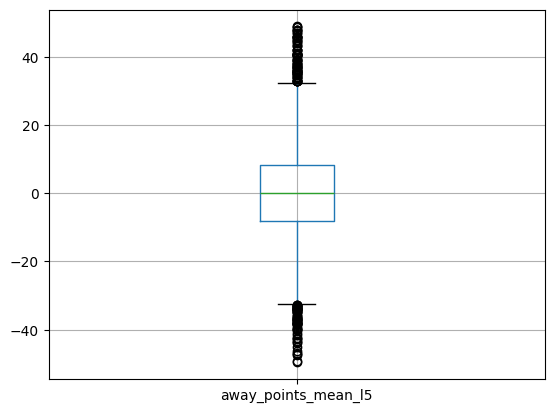

In [622]:
rda[['away_points_mean_l5']].boxplot()

In [623]:
rda.shape

(3596, 24)

In [624]:
df=rda 

nous avons visualiser les donnes avec boxplot et nous avons identifier en tenant compte de le realiter les minimum et les maximum et en fonction de ca nous avons emputer les valeurs aberantes

## Traitement des données catégoriques

In [625]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
print("Colonnes catégorielles :", cat_cols)

Colonnes catégorielles : Index(['date', 'home_team', 'away_team', 'match_type'], dtype='object')


### Date

In [626]:
df["date"] = pd.to_datetime(df["date"]) # transformation de la date au format datetime


competition["date"] = pd.to_datetime(competition["date"]) # transformation de la date au format datetime pour competition

In [627]:
df['date'] = (df['date'] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1D')# convertion en durée à partir de la date référentielle 1970-01-01
 
competition['date'] = (competition['date'] - pd.Timestamp("1970-01-01")) // pd.Timedelta('1D')# convertion en durée à partir de la date référentielle 1970-01-01

### home_team et away_team

In [628]:
compte = df['home_team'].value_counts()
df['home_team'] = df['home_team'].map(compte)


compte = competition['home_team'].value_counts()
competition['home_team'] = competition['home_team'].map(compte)

#encodage

In [629]:
compte = df['away_team'].value_counts()
df['away_team'] = df['away_team'].map(compte)

compte = competition['away_team'].value_counts()
competition['away_team'] = competition['away_team'].map(compte)

#encodage

### match_type

In [630]:
df['match_type'].value_counts()

match_type
Friendly       2575
Competition    1021
Name: count, dtype: int64

#### Nous avons juste deux occurrences donc nous l'encodons en OHE

In [631]:
df_encoder=pd.get_dummies(df,columns=['match_type'])

competition=pd.get_dummies(competition,columns=['match_type'])

### Id

In [632]:
df_encoder=df_encoder.drop(columns=['id'])


competition=competition.drop(columns=['id'])

In [633]:
df_encoder.columns

Index(['date', 'home_team', 'away_team', 'rank_change_home',
       'rank_change_away', 'home_goals_mean', 'home_goals_mean_l5',
       'home_goals_suf_mean', 'home_goals_suf_mean_l5', 'home_rank_mean',
       'home_rank_mean_l5', 'home_points_mean', 'home_points_mean_l5',
       'away_goals_mean', 'away_goals_mean_l5', 'away_goals_suf_mean',
       'away_goals_suf_mean_l5', 'away_rank_mean', 'away_rank_mean_l5',
       'away_points_mean', 'away_points_mean_l5', 'target',
       'match_type_Competition', 'match_type_Friendly'],
      dtype='object')

#### cette etape marque l'encodage des variables catégoriques et le nettoyage des colonnes pour préparer les données à l’analyse.

## Séparation des données 

### Separation caractéristiques et étiquette

In [634]:
X=df_encoder.drop(columns=['target'])
y=df_encoder['target']

#### X contient toutes les caractéristiques sauf target et y contient uniquement target, qui représente l’étiquette 

### Separation des données en train et test

In [635]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y)

#### train est utilisé pour entraîner le modèle et test est utilisé pour évaluer ses performances.

## Données manquantes

#### la gestion des valeurs manquantes avant l'entraînement d'un modèle est importante.

In [636]:
df_encoder.isna().sum()
# nous verifions ici les valeurs manquante dans nos donnes DataFrame

date                         0
home_team                    0
away_team                    0
rank_change_home             0
rank_change_away          1950
home_goals_mean              0
home_goals_mean_l5           0
home_goals_suf_mean         22
home_goals_suf_mean_l5       0
home_rank_mean               0
home_rank_mean_l5            0
home_points_mean            14
home_points_mean_l5          0
away_goals_mean              0
away_goals_mean_l5           0
away_goals_suf_mean         17
away_goals_suf_mean_l5       0
away_rank_mean               0
away_rank_mean_l5            0
away_points_mean             0
away_points_mean_l5          0
target                       0
match_type_Competition       0
match_type_Friendly          0
dtype: int64

#### il y'a des valeurs manquantes a gerer

In [637]:
competition.isna().sum()
# nous verifions ici les valeurs manquante dans notre DataFrame competition

date                      0
home_team                 0
away_team                 0
rank_change_home          0
rank_change_away          0
home_goals_mean           0
home_goals_mean_l5        0
home_goals_suf_mean       0
home_goals_suf_mean_l5    0
home_rank_mean            0
home_rank_mean_l5         0
home_points_mean          0
home_points_mean_l5       0
away_goals_mean           0
away_goals_mean_l5        0
away_goals_suf_mean       0
away_goals_suf_mean_l5    0
away_rank_mean            0
away_rank_mean_l5         0
away_points_mean          0
away_points_mean_l5       0
match_type_Competition    0
match_type_Friendly       0
dtype: int64

#### il n'a auccune valeur manquante dans competition

### rank_change_away          2042


In [638]:
df['rank_change_away'].describe()

count    1646.000000
mean        0.055893
std         1.967032
min        -9.000000
25%        -1.000000
50%         0.000000
75%         1.000000
max         9.000000
Name: rank_change_away, dtype: float64

#### Moyenne (mean) : ~0.04
#### Médiane (median) : 0.0
#### La médiane est plus fiable que la moyenne en présence de valeurs extrêmes.

In [639]:
X_train['rank_change_away'].median()

np.float64(0.0)

In [640]:
X_train['rank_change_away']=X_train['rank_change_away'].fillna(X_train['rank_change_away'].median())
X_test['rank_change_away']=X_test['rank_change_away'].fillna(X_train['rank_change_away'].median())

# Imputation des valeurs manquantes avec la médiane car La majorité des valeurs sont proches de zéro, donc la médiane (0.0) est une bonne estimation.

### home_goals_suf_mean         24


In [641]:
df['home_goals_suf_mean'].describe()

count    3574.000000
mean        1.251320
std         0.667300
min         0.000000
25%         0.857143
50%         1.128205
75%         1.500000
max        11.000000
Name: home_goals_suf_mean, dtype: float64

In [642]:
X_train['home_goals_suf_mean'].median()

np.float64(1.1327044025157234)

In [643]:
X_train['home_goals_suf_mean']=X_train['home_goals_suf_mean'].fillna(X_train['home_goals_suf_mean'].median())
X_test['home_goals_suf_mean']=X_test['home_goals_suf_mean'].fillna(X_train['home_goals_suf_mean'].median())

# Imputation des valeurs manquantes avec la médiane


### home_points_mean            14


In [644]:
df['home_points_mean'].describe()

count    3582.000000
mean       18.714308
std        60.864292
min      -166.940000
25%       -16.000000
50%         7.000000
75%        47.045000
max       287.290000
Name: home_points_mean, dtype: float64

In [645]:
X_train['home_points_mean'].median()

np.float64(6.960000000000036)

In [646]:
X_train['home_points_mean']=X_train['home_points_mean'].fillna(X_train['home_points_mean'].median())
X_test['home_points_mean']=X_test['home_points_mean'].fillna(X_train['home_points_mean'].median())

# Imputation avec la médiane.

####  Valeurs négatives et très élevées entraine possibilité de problèmes dans les données, donc la médiane réduit ce risque.

### away_goals_suf_mean         17


In [647]:
df['away_goals_suf_mean'].describe()

count    3579.000000
mean        1.321989
std         0.737492
min         0.000000
25%         0.912662
50%         1.186047
75%         1.583333
max         9.500000
Name: away_goals_suf_mean, dtype: float64

In [648]:
X_train['away_goals_suf_mean'].median()

np.float64(1.1895777178796045)

In [649]:
X_train['away_goals_suf_mean']=X_train['away_goals_suf_mean'].fillna(X_train['away_goals_suf_mean'].median())
X_test['away_goals_suf_mean']=X_test['away_goals_suf_mean'].fillna(X_train['away_goals_suf_mean'].median())

# Imputation avec la médiane

In [650]:
X_train.isna().sum()

date                      0
home_team                 0
away_team                 0
rank_change_home          0
rank_change_away          0
home_goals_mean           0
home_goals_mean_l5        0
home_goals_suf_mean       0
home_goals_suf_mean_l5    0
home_rank_mean            0
home_rank_mean_l5         0
home_points_mean          0
home_points_mean_l5       0
away_goals_mean           0
away_goals_mean_l5        0
away_goals_suf_mean       0
away_goals_suf_mean_l5    0
away_rank_mean            0
away_rank_mean_l5         0
away_points_mean          0
away_points_mean_l5       0
match_type_Competition    0
match_type_Friendly       0
dtype: int64

## Normalisation

array([[<Axes: title={'center': 'date'}>,
        <Axes: title={'center': 'home_team'}>,
        <Axes: title={'center': 'away_team'}>,
        <Axes: title={'center': 'rank_change_home'}>,
        <Axes: title={'center': 'rank_change_away'}>],
       [<Axes: title={'center': 'home_goals_mean'}>,
        <Axes: title={'center': 'home_goals_mean_l5'}>,
        <Axes: title={'center': 'home_goals_suf_mean'}>,
        <Axes: title={'center': 'home_goals_suf_mean_l5'}>,
        <Axes: title={'center': 'home_rank_mean'}>],
       [<Axes: title={'center': 'home_rank_mean_l5'}>,
        <Axes: title={'center': 'home_points_mean'}>,
        <Axes: title={'center': 'home_points_mean_l5'}>,
        <Axes: title={'center': 'away_goals_mean'}>,
        <Axes: title={'center': 'away_goals_mean_l5'}>],
       [<Axes: title={'center': 'away_goals_suf_mean'}>,
        <Axes: title={'center': 'away_goals_suf_mean_l5'}>,
        <Axes: title={'center': 'away_rank_mean'}>,
        <Axes: title={'center':

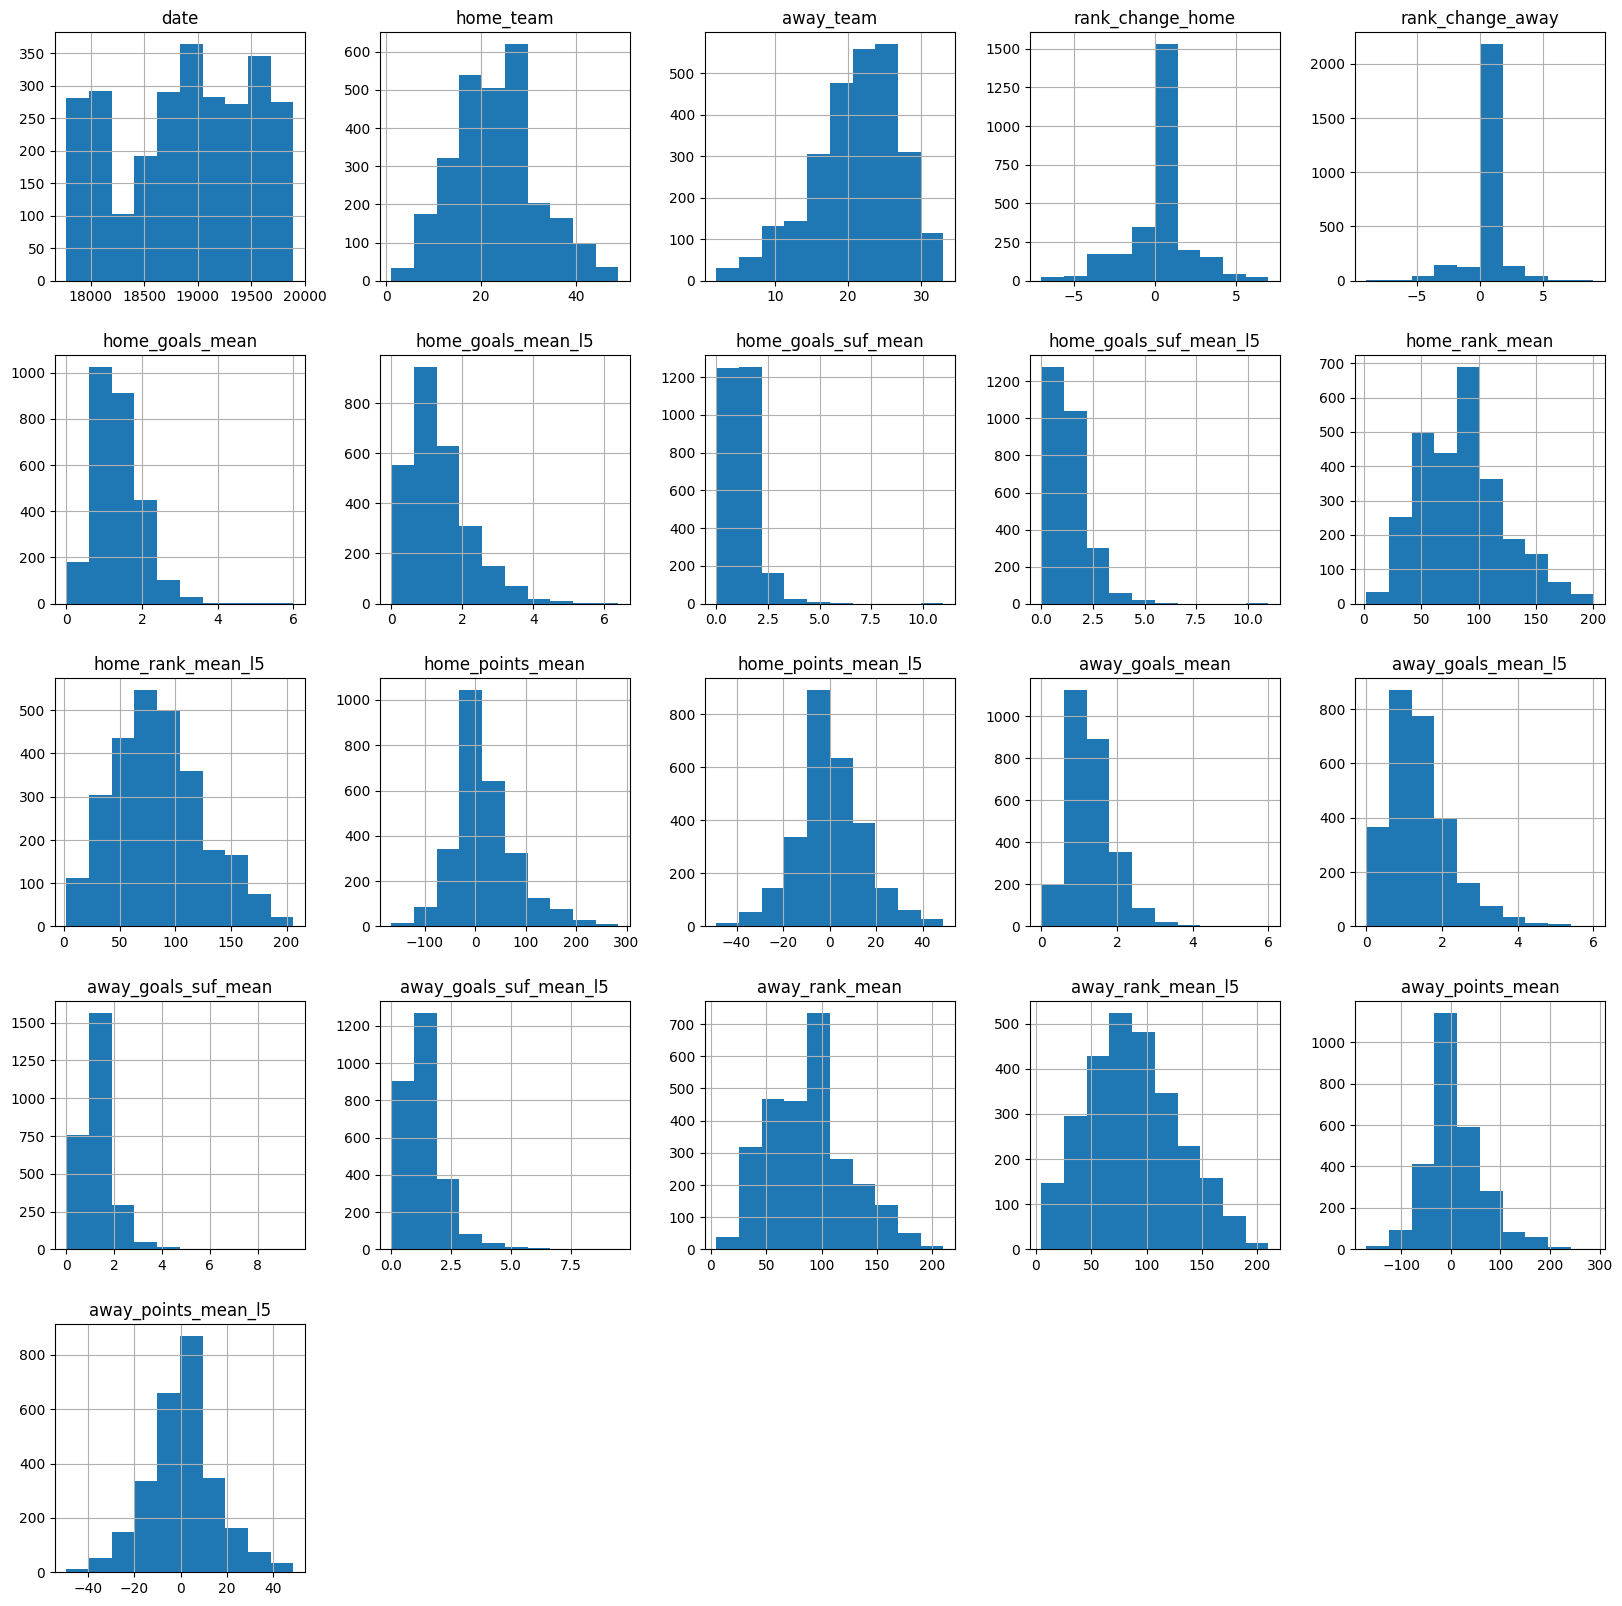

In [651]:
X_train.hist(figsize= (20, 20))

#### Certaines variables sont bien distribuées de manière normale, comme away_goals_mean, home_points_mean et d'autres ont une distribution asymétrique avec une forte concentration de valeurs vers 0 ou des valeurs extrêmes (rank_change_away, home_rank_mean, away_points_mean).

In [652]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.set_output(transform='pandas')
scaler.fit(X_train) # pour éviter la fuite des données
X_train=scaler.transform(X_train)
X_test=scaler.transform(X_test)

competition=scaler.transform(competition)

#### On se penche vers la standardization parce que les donnees ne sont pas distribuer normalement et la stantardization Permet d'éviter des différences d’échelle entre les variables.

In [653]:
competition.head()

,date,home_team,away_team,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,...,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,match_type_Competition,match_type_Friendly
0,0.588015,-1.579831,-2.566157,-0.008591,-0.010566,0.663502,0.054438,-0.565503,-0.345291,-0.619051,...,0.803120,1.063571,-0.287946,-0.366986,-0.933766,-1.128441,1.428914,0.107266,-0.630404,0.630404
1,0.071170,-2.031510,-2.395325,2.624460,-3.010317,-1.074988,-0.894572,-0.234594,0.127005,0.491985,...,-0.362714,0.101380,-1.162961,-1.238478,0.023732,-0.130234,-0.372589,-0.055391,-0.630404,0.630404
2,-1.702030,-1.692750,-2.053661,2.624460,-1.510442,-2.247517,-1.606330,2.376881,1.780040,0.890264,...,0.477771,0.341928,-1.777333,-1.456351,1.505498,1.352396,-0.151262,0.039773,-0.630404,0.630404
3,-1.497243,-1.579831,-2.736990,1.571240,-0.010566,0.230783,0.054438,0.128111,0.127005,1.327042,...,2.104516,1.544666,-0.168795,-0.149113,1.648231,1.479619,-0.151262,0.039773,-0.630404,0.630404
4,0.069545,-2.031510,-2.395325,1.571240,-0.010566,0.100346,-0.182814,-0.302276,0.127005,-0.894918,...,0.813615,1.544666,0.384680,0.940252,-0.759807,-0.330854,0.789996,1.464547,-0.630404,0.630404


# Création de modèle

### Model  linéaire

In [654]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score,recall_score,precision_score, accuracy_score

In [655]:
from sklearn.linear_model import LogisticRegression
model_logictic=LogisticRegression()
model_logictic.fit(X_train,y_train)
y_pred=model_logictic.predict(X_test)

print(f"accuracy_score { accuracy_score(y_test,y_pred)}")
print(f"f1_score { f1_score(y_test,y_pred)}")
print(f"recall_score { recall_score(y_test,y_pred)}")
print(f"precision_score { precision_score(y_test,y_pred)}")

accuracy_score 0.7119021134593994
f1_score 0.7304890738813735
recall_score 0.7237113402061855
precision_score 0.7373949579831933


In [656]:
from sklearn.linear_model import LogisticRegression
model_logictic=LogisticRegression(penalty='l1', solver='saga')
model_logictic.fit(X_train,y_train)
y_pred=model_logictic.predict(X_test)

print(f"accuracy_score{ accuracy_score(y_test,y_pred)}")

accuracy_score0.7119021134593994


####  Résultat légèrement meilleur que la logistique standard, mais sans grande différence

In [657]:
from sklearn.neighbors import KNeighborsClassifier
model_KNN= KNeighborsClassifier()
model_KNN.fit(X_train,y_train)
y_pred=model_KNN.predict(X_test)

print(f"accuracy_score { accuracy_score(y_test,y_pred)}")
print(f"f1_score { f1_score(y_test,y_pred)}")
print(f"recall_score { recall_score(y_test,y_pred)}")

accuracy_score 0.6484983314794216
f1_score 0.6673684210526316
recall_score 0.6536082474226804


#### Performances plus faibles que la régression logistique.

In [658]:
from sklearn.neighbors import KNeighborsClassifier
model_KNN= KNeighborsClassifier(n_neighbors=10)
model_KNN.fit(X_train,y_train)
y_pred=model_KNN.predict(X_test)

print(f"accuracy_score { accuracy_score(y_test,y_pred)}")
print(f"f1_score { f1_score(y_test,y_pred)}")
print(f"recall_score { recall_score(y_test,y_pred)}")
print(f"prediction score { precision_score(y_test,y_pred)}")

accuracy_score 0.6662958843159066
f1_score 0.6666666666666666
recall_score 0.6185567010309279
prediction score 0.7228915662650602


#### KNN sous-performe par rapport à la Régression Logistique

## Modèle de machine à vecteur support

In [659]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
model_svc = SVC()
model_svc.fit(X_train, y_train) # Entraîner le modèle sur les données d'entraînement
y_pred = model_svc.predict(X_test) # Prédire les classes sur les données de test

print(f"accuracy_score { accuracy_score(y_test,y_pred)}")
print(f"f1_score { f1_score(y_test,y_pred)}")
print(f"recall_score { recall_score(y_test,y_pred)}")

accuracy_score 0.6885428253615128
f1_score 0.7014925373134329
recall_score 0.6783505154639176


#### SVM offre de meilleures performances que KNN.

## Modèle à base d'arbre

In [660]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
model_tree = DecisionTreeClassifier() # Initialiser le modèle d'arbre de décision

model_tree.fit(X_train, y_train) # Entraîner le modèle sur les données d'entraînement
y_pred = model_tree.predict(X_test) # Prédire les classes sur les données de test

print(f"accuracy_score { accuracy_score(y_test,y_pred)}")
print(f"f1_score { f1_score(y_test,y_pred)}")
print(f"recall_score { recall_score(y_test,y_pred)}")

accuracy_score 0.5862068965517241
f1_score 0.6067653276955602
recall_score 0.5917525773195876


#### Un arbre de décision simple est souvent trop sensible aux données d'entraînement 

In [661]:
from sklearn.ensemble import RandomForestClassifier
model_RandomForestClassifier = RandomForestClassifier(n_estimators=100) # Initialiser le modèle d'arbre de décision

model_RandomForestClassifier.fit(X_train, y_train) # Entraîner le modèle sur les données d'entraînement
y_pred = model_RandomForestClassifier.predict(X_test) # Prédire les classes sur les données de test

print(f"accuracy_score { accuracy_score(y_test,y_pred)}")
print(f"f1_score { f1_score(y_test,y_pred)}")
print(f"recall_score { recall_score(y_test,y_pred)}")
print(f"précision { precision_score(y_test,y_pred)}")

accuracy_score 0.699666295884316
f1_score 0.7121535181236673
recall_score 0.688659793814433
précision 0.7373068432671082


####  Amélioration claire par rapport à DecisionTree.

In [662]:
from sklearn.linear_model import LogisticRegression
model_logictic=LogisticRegression()
model_logictic.fit(X_train,y_train)
y_pred=model_logictic.predict(X_test)

y_pred = model_logictic.predict(competition)

from sklearn.ensemble import RandomForestClassifier
model_RandomForestClassifier = RandomForestClassifier(n_estimators=100) # Initialiser le modèle d'arbre de décision

model_RandomForestClassifier.fit(X_train, y_train) # Entraîner le modèle sur les données d'entraînement
y_pred = model_RandomForestClassifier.predict(X_test) # Prédire les classes sur les données de test

print(f"accuracy_score { accuracy_score(y_test,y_pred)}")
print(f"f1_score { f1_score(y_test,y_pred)}")
print(f"recall_score { recall_score(y_test,y_pred)}")
print(f"précision { precision_score(y_test,y_pred)}")

accuracy_score 0.6885428253615128
f1_score 0.70276008492569
recall_score 0.6824742268041237
précision 0.7242888402625821


In [663]:
from sklearn.linear_model  import LogisticRegression 
model_logictic= LogisticRegression()
model_logictic.fit(X_train,y_train)
y_pred = model_logictic.predict(X_test)
y_pred = model_logictic.predict(competition)

In [664]:
y_pred

array([1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0,

Evaluation compéttion

In [665]:
competition.head()

,date,home_team,away_team,rank_change_home,rank_change_away,home_goals_mean,home_goals_mean_l5,home_goals_suf_mean,home_goals_suf_mean_l5,home_rank_mean,...,away_goals_mean,away_goals_mean_l5,away_goals_suf_mean,away_goals_suf_mean_l5,away_rank_mean,away_rank_mean_l5,away_points_mean,away_points_mean_l5,match_type_Competition,match_type_Friendly
0,0.588015,-1.579831,-2.566157,-0.008591,-0.010566,0.663502,0.054438,-0.565503,-0.345291,-0.619051,...,0.803120,1.063571,-0.287946,-0.366986,-0.933766,-1.128441,1.428914,0.107266,-0.630404,0.630404
1,0.071170,-2.031510,-2.395325,2.624460,-3.010317,-1.074988,-0.894572,-0.234594,0.127005,0.491985,...,-0.362714,0.101380,-1.162961,-1.238478,0.023732,-0.130234,-0.372589,-0.055391,-0.630404,0.630404
2,-1.702030,-1.692750,-2.053661,2.624460,-1.510442,-2.247517,-1.606330,2.376881,1.780040,0.890264,...,0.477771,0.341928,-1.777333,-1.456351,1.505498,1.352396,-0.151262,0.039773,-0.630404,0.630404
3,-1.497243,-1.579831,-2.736990,1.571240,-0.010566,0.230783,0.054438,0.128111,0.127005,1.327042,...,2.104516,1.544666,-0.168795,-0.149113,1.648231,1.479619,-0.151262,0.039773,-0.630404,0.630404
4,0.069545,-2.031510,-2.395325,1.571240,-0.010566,0.100346,-0.182814,-0.302276,0.127005,-0.894918,...,0.813615,1.544666,0.384680,0.940252,-0.759807,-0.330854,0.789996,1.464547,-0.630404,0.630404


In [666]:
cop=pd.read_csv('exemple_soumission.csv')


In [667]:
y_pred

# Convertir les prédictions en DataFrame

df_result = pd.DataFrame({'id': competition_base['id'].values, 'target': y_pred})


# Sauvegarder en CSV
df_result.to_csv("soumission_kaggle.csv", index=False)

print("Fichier CSV enregistré : soumission_kaggle.csv")

Fichier CSV enregistré : soumission_kaggle.csv


# Evaluation des modèles par modification des hyperparamètres

variation de C : parametre de régularisation

In [668]:
import numpy as np

from sklearn.linear_model import LogisticRegression
k_list=[1,2,4, 6, 10]
result={}

for k in k_list:
    model_logictic=LogisticRegression( C=k)
    model_logictic.fit(X_train,y_train)
    y_pred=model_logictic.predict(X_test)
    name="model_logictic",k

    print(f"accuracy_score { accuracy_score(y_test,y_pred)}")
    print(f"f1_score { f1_score(y_test,y_pred)}")
    print(f"recall_score { recall_score(y_test,y_pred)}")
    result[name]=accuracy_score(y_test,y_pred)
    
print('')    

print(result)
print(f"meilleur score {max(result, key=result.get)}")



accuracy_score 0.7119021134593994
f1_score 0.7304890738813735
recall_score 0.7237113402061855
accuracy_score 0.7130144605116796
f1_score 0.7318087318087318
recall_score 0.7257731958762886
accuracy_score 0.7119021134593994
f1_score 0.731048805815161
recall_score 0.7257731958762886
accuracy_score 0.7119021134593994
f1_score 0.731048805815161
recall_score 0.7257731958762886
accuracy_score 0.7119021134593994
f1_score 0.731048805815161
recall_score 0.7257731958762886

{('model_logictic', 1): 0.7119021134593994, ('model_logictic', 2): 0.7130144605116796, ('model_logictic', 4): 0.7119021134593994, ('model_logictic', 6): 0.7119021134593994, ('model_logictic', 10): 0.7119021134593994}
meilleur score ('model_logictic', 2)


Nous avons testé plusieurs valeurs du paramètre C dans un modèle de régression logistique afin d’optimiser ses performances sur notre jeu de données.Après avoir testé plusieurs valeurs de C, nous avons déterminé que la meilleure performance a été obtenue avec C = 1 


In [669]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import confusion_matrix
model_logictic=LogisticRegression()
model_logictic.fit(X_train,y_train)
y_pred=model_logictic.predict(X_test)

y_pred = model_logictic.predict(competition)

from sklearn.ensemble import RandomForestClassifier
model_RandomForestClassifier = RandomForestClassifier(n_estimators=100) # Initialiser le modèle d'arbre de décision

model_RandomForestClassifier.fit(X_train, y_train) # Entraîner le modèle sur les données d'entraînement
y_pred = model_RandomForestClassifier.predict(X_test) # Prédire les classes sur les données de test

print(f"accuracy_score { accuracy_score(y_test,y_pred)}")

print(f"f1_score { f1_score(y_test,y_pred)}")
print(f"recall_score { recall_score(y_test,y_pred)}")
print(f"précision { precision_score(y_test,y_pred)}")

print(" ")

print(f"matrice de confusion { confusion_matrix(y_test,y_pred)}")


accuracy_score 0.6852057842046718
f1_score 0.6947141316073355
recall_score 0.6639175257731958
précision 0.7285067873303167
 
matrice de confusion [[294 120]
 [163 322]]


L’objectif du projet était de prédire les résultats de matchs de football à partir d’un jeu de données. Pour y arriver, nous avons explorer et nettoyé les données (en traitant les valeurs aberrantes et les données manquantes), puis testé plusieurs modèles d’apprentissage automatique pour voir lequel donnait les meilleurs résultats.nous avons découvert plein de choses en explorant les données :Il y avait des valeurs aberrantes dans certaines colonnes Certaines données étaient manquantes et ont dû être remplacées. le target était bien équilibrée, ce qui a facilite l’apprentissage des modèles.


ensuite nous avons testre plusieur modeles et la Régression Logistique etait notre meilleur modèle avec 71% de précision.
le model KNN a une performances moyennes, le model SVM a un bon modèle 
 Le pire modèle que nous avons testé était l'Arbre de Décision (DecisionTreeClassifier). Il s'est surentraîné sur les données d'entraînement
 mais il a mal généralisé sur les données de test. Il a obtenu une accuracy d'environ 61%, ce qui est inférieur à tous les autres modèles testés.
Au final, la régression logistique s’est révélée être le modèle le plus performant.

